# **Shanta Gold Leaching Model Development Notebook**

This notebook supports the structured development, validation, and tuning of gold dissolution and cyanide consumption models for Shanta Gold's processing circuit.

---

## 📦 Load Data and Setup

In [12]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from typing import Callable, List, Tuple
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

df_site = pd.read_excel("site_leaching_data.xlsx", sheet_name=0)

# Clean column names: strip whitespace and unify format
def clean_column_name(col):
	col = col.strip()
	col = re.sub(r'\s+', '_', col)
	col = re.sub(r'[^\w\d_]', '', col)
	# Remove double underscores
	col = re.sub(r'__+', '_', col)
	# Convert to lowercase
	col = col.lower()
	# Capitablize first letter and each letter after an underscore
	col = col.replace('_', ' ').title().replace(' ', '_')
	return col

df_site.columns = [clean_column_name(col) for col in df_site.columns]

# Save cleaned DataFrame to pickle for future use
df_site.to_pickle("cleaned_site_data.pkl")

# Save cleaned DataFrame to csv for easier access
df_site.to_csv("cleaned_site_data.csv", index=False)

### 🔍 Dataset Summary

In [13]:
print("Rows:", df_site.shape[0])
print("Columns:", df_site.shape[1])
df_site.describe(include='all').T.head()

Rows: 334
Columns: 103


,count,mean,min,25%,50%,75%,max,std
Date,334,2024-11-14 12:00:00,2024-06-01 00:00:00,2024-08-23 06:00:00,2024-11-14 12:00:00,2025-02-05 18:00:00,2025-04-30 00:00:00,NaN
Leach_Feed_Throughput_M3Hr,334.0,149.069628,82.251427,139.231245,143.532969,149.047893,290.862774,25.847754
Leach_Feed_Throughput_M3Day,334.0,3361.034649,947.769899,3250.077557,3401.969683,3551.990909,6206.879399,668.362032
Percentsolids,334.0,49.118174,31.4,49.131159,50.0,51.072917,55.208333,4.060619
Leach_Feed_Grade_Au_Gt_Ds,334.0,2.098886,0.0,1.76,2.155,2.44,4.13,0.623796


## Define constants and parameters

In [14]:
# Define static tank volumes
tank_config = {
	"Cyanide_Profile_Ppm_Leach_Tank_1": 1000,
	"Cyanide_Profile_Ppm_Leach_Tank_2": 1000,
	"Cyanide_Profile_Ppm_Cil_Tank_1": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_2": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_3": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_4": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_5": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_6": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_7": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_8": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_9": 250,
}
total_circuit_volume = sum(tank_config.values())
cn_decay_factor = 0.85  			# % CN that remains from one tank to the next in the series
max_nacn_drawdown = 12
d = 20 								# ore particle size µm
particle_size_threshold = 50 		# µm
locked_gold_threshold = 0.02 		# 5%
liberation_fraction = 1 - locked_gold_threshold
density = 2.7  						# assumed pulp density in kg/L
pulp_density = 1.5  				# kg/L
total_residence_time = 30 				# hours
outlier_thresholds = {
	'Nacn_Used_T': (0, 10),  					# t NaCN used per day
	'Daily_Nacn_Consumption_Kgt': (0, 10),		# kg NaCN consumed per tonne of ore
	'MTD_Nacn_Consumption_Kgt': (0, 10)			# kg NaCN consumed per tonne of ore
}
solid_density = 2.7  	# t/m³
liquid_density = 1.0  	# t/m³ (mostly water, even after dilution)

## 🧹 Cleanse the Dataset

In [15]:
def cleanse_data(df):
	"""
	Revised data cleansing function that:
	- Interpolates oxygen sensor values
	- Flags CN dosing tanks
	- Filters outliers in NaCN usage (≤ 6 t/day)
	- Imputes missing NaCN values safely
	- Calculates estimated CN consumption from tank concentration + feed volume
	- Provides both cumulative rolling and true calendar MTD NaCN metrics
	- Outputs final blended daily CN consumption estimate
	"""

	# --- Identify relevant columns ---
	cn_cols = [col for col in df.columns if col.startswith("Cyanide_Profile_Ppm")]
	o2_cols = [col for col in df.columns if col.startswith("Dissolved_Oxygen_Profile_Ppm")]

	# --- Step 1: CN tank dosing flags ---
	df["Cn_Adds_To_Tank_1"] = df["Cyanide_Profile_Ppm_Leach_Tank_1"].fillna(0) > 50
	df["Cn_Adds_To_Tank_2"] = df["Cyanide_Profile_Ppm_Leach_Tank_2"].fillna(0) > 50

	# --- Step 2: Improved CN ppm imputation ---
	cn_temp = df[cn_cols].copy()
	missing_all_cn = cn_temp.isna().all(axis=1)
	cn_temp_imputed = cn_temp.ffill(axis=1).bfill(axis=1)
	df["CN_ppm"] = cn_temp_imputed.mean(axis=1)
	df["All_CN_Cols_Missing"] = missing_all_cn

	# --- Step 3: Impute oxygen ---
	for col in o2_cols:
		is_missing_or_zero = df[col].replace(0.0, np.nan).isna()
		median_val = df[col].replace(0.0, np.nan).median()
		df[col] = df[col].replace(0.0, np.nan).fillna(median_val)
		df[f"{col}_imputed"] = is_missing_or_zero

	df["O2_ppm"] = df[o2_cols].mean(axis=1)
	df["O2_row_fully_imputed"] = df[[f"{col}_imputed" for col in o2_cols]].all(axis=1)

	# --- Step 4: Filter and safely impute NaCN usage ---
	df["Nacn_Used_T_Cleaned"] = df["Nacn_Used_T"].where(df["Nacn_Used_T"] <= max_nacn_drawdown)
	impute_target = df["Nacn_Used_T_Cleaned"].copy()
	impute_target[df["Nacn_Used_T_Cleaned"] == 0] = np.nan  # Preserve zeroes
	df["Nacn_Used_T_Cleaned_Imputed"] = impute_target.interpolate(method="linear", limit_direction="both")
	df["Nacn_Used_T_Final"] = df["Nacn_Used_T_Cleaned"].fillna(df["Nacn_Used_T_Cleaned_Imputed"])
	df["NaCN_Used_kg"] = df["Nacn_Used_T_Final"] * 1000

	# --- Step 5: Estimate pulp density and dry tonnes ---
	df["Pulp_Density_Calc"] = (
		(df["Percentsolids"] / 100) * solid_density +
		(1 - df["Percentsolids"] / 100) * liquid_density
	)
	df["Dry_Tonnes_Est_From_Volume"] = (
		df["Leach_Feed_Throughput_M3Day"] *
		df["Pulp_Density_Calc"] *
		(df["Percentsolids"] / 100)
	)

	# --- Step 6: Estimate CN from tank ppm using reference pulp density ---
	pulp_density_ref = 1.5
	tank_cn = df[["Cyanide_Profile_Ppm_Leach_Tank_1", "Cyanide_Profile_Ppm_Leach_Tank_2"]].mean(axis=1)
	df["Est_Cn_Consumption_Kg_TonsDryAdj"] = tank_cn * (df["Dry_Tonnes_Est_From_Volume"] / pulp_density_ref) / 1000

	# --- Step 7: Usage-based fallback logic ---
	df["Daily_Nacn_Consumption_Kgt_Recalc"] = df["NaCN_Used_kg"] / df["Daily_Milledtreated_Tons"]
	df["Cumulative_NaCN_Used_kg"] = df["NaCN_Used_kg"].cumsum()
	df["Cumulative_Tonnes"] = df["Daily_Milledtreated_Tons"].cumsum()

	df["Rolling_Cumulative_Nacn_Consumption_Kgt"] = df["Cumulative_NaCN_Used_kg"] / df["Cumulative_Tonnes"]
	df["Month"] = df["Date"].dt.to_period("M")
	df["Mtd_Nacn_Consumption_Kgt_True"] = (
		df["NaCN_Used_kg"].groupby(df["Month"]).cumsum() /
		df["Daily_Milledtreated_Tons"].groupby(df["Month"]).cumsum()
	)

	df["Mtd_Nacn_Consumption_Kgt_Filled"] = df["Rolling_Cumulative_Nacn_Consumption_Kgt"].interpolate(method="linear").ffill()
	df["Calc_Daily_Nacn_Consumption_Kgt"] = df["Mtd_Nacn_Consumption_Kgt_Filled"].diff().fillna(0)
	df["Daily_Nacn_Consumption_Kgt_Final"] = df["Daily_Nacn_Consumption_Kgt_Recalc"].fillna(df["Calc_Daily_Nacn_Consumption_Kgt"])

	# --- Step 8: Final blended estimate ---
	df["Cn_Consumed_Kg_Estimate"] = (
		0.9 * df["Est_Cn_Consumption_Kg_TonsDryAdj"] +
		0.1 * df["Daily_Nacn_Consumption_Kgt_Final"] * df["Daily_Milledtreated_Tons"]
	)

	return df

# Apply the cleansing function
df_site_cleaned = cleanse_data(df_site)

**Cyanide Consumption Estimation – Cleaned and Derived Fields**
| Field                                     | Description                                                                     | Key Use Case                         |
| ----------------------------------------- | ------------------------------------------------------------------------------- | ------------------------------------ |
| `Cn_Adds_To_Tank_1` / `_Tank_2`           | Boolean flags for CN dosing in each leach tank (ppm > 50).                      | Diagnose dosing behaviour            |
| `CN_ppm`                                  | Daily average CN concentration across all tanks (using ffill/bfill imputation). | General CN strength indicator        |
| `All_CN_Cols_Missing`                     | Flags rows with no original CN data before imputation.                          | Confidence filtering                 |
| `O2_ppm`                                  | Avg dissolved oxygen across all tanks (zero/NaN → median).                      | Oxygen availability for kinetics     |
| `O2_row_fully_imputed`                    | Flags rows with all oxygen data imputed.                                        | Confidence filtering                 |
| `Nacn_Used_T` *(raw)*                     | Warehouse drawdown (t/day). May include batching, prep, or offsite transfer.    | ⚠ Not suitable for modelling         |
| `Nacn_Used_T_Cleaned`                     | Outliers (>6 t) masked.                                                         | Better for diagnostics               |
| `Nacn_Used_T_Cleaned_Imputed`             | Interpolated drawdown (t/day), gaps filled.                                     | ✅ Visualisation and inventory trends |
| `NaCN_Used_kg`                            | Cleaned/imputed drawdown in kilograms.                                          | Intermediate mass-based calculations |
| `Pulp_Density_Calc`                       | Estimated pulp density from % solids.                                           | Internal calc.                       |
| `Est_Cn_Consumption_Kg_Tank`              | Estimated CN input (kg) from leach tank ppm and feed volume.                    | ✅ Simulation and model input         |
| `Rolling_Cumulative_Nacn_Consumption_Kgt` | Cumulative CN usage (kg/t), smoothed over time.                                 | Long-term trendlines                 |
| `Mtd_Nacn_Consumption_Kgt_True`           | ✅ True month-to-date CN usage (kg/t).                                           | ✅ Reporting & dashboards             |
| `Mtd_Nacn_Consumption_Kgt_Filled`         | Smoothed fallback version of MTD.                                               | Internal use                         |
| `Daily_Nacn_Consumption_Kgt_Recalc`       | Recalculated CN usage per tonne (kg/t) from drawdown.                           | Diagnostics & fallback logic         |
| `Calc_Daily_Nacn_Consumption_Kgt`         | Derived daily kg/t from filled MTD deltas.                                      | Fallback only                        |
| `Daily_Nacn_Consumption_Kgt_Final`        | ✅ Final kg/t CN usage per day (recalc + fallback logic).                        | ✅ Modelling, visualisation, ML input |
| `Cn_Consumed_Kg_Estimate`                 | ✅ Final CN input (kg/day): 90% tank estimate + 10% warehouse.                   | ✅ Primary simulation input field     |


**Quick Reference Summary**
| Task                             | Best Field                               |
| -------------------------------- | ---------------------------------------- |
| **Model input (CN kg/day)**      | `Cn_Consumed_Kg_Estimate`                |
| **Model input (CN kg/t)**        | `Daily_Nacn_Consumption_Kgt_Final`       |
| **Monthly reports / dashboards** | `Mtd_Nacn_Consumption_Kgt_True`          |
| **Warehouse drawdown trends**    | `Nacn_Used_T_Cleaned_Imputed`            |
| **Operational dosing review**    | `Cn_Adds_To_Tank_1`, `Cn_Adds_To_Tank_2` |

## 📊 Define Helper Functions for Visualisations

In [16]:
def_colours = ["#0099CC", "#003366", "#BDDB94", "#BBBDC0", "#6CBCE3",
			   "#A6D2EC", "#C00000", "#FFC000", "#00B050", "#7030A0"] 

# Single-line plot
def plot_line(x, y, title="Line Plot", 
				   y_label="Value",
				   x_label="Services",
				   colour = None
				   ):
	if colour is None:
		colour = def_colours[0]
	plt.figure(figsize=(10, 6))
	plt.plot(x, y, label=y_label, marker='o', color=colour)
	plt.xticks(rotation=45)
	# plt.xlabel(x_title)
	# plt.ylabel(y_title)
	plt.title(title)
	plt.legend()
	plt.grid(True)
	plt.tight_layout()
	plt.show()

# Dual-line plot
def plot_line_dual(col1, col2, x,
				   col1_label="Predicted % Dissolved",
				   col2_label="Actual % Dissolved",
				   x_title="Tank", y_title="Gold Dissolution (%)",
				   title="Gold Dissolution Comparison"):
	
	colour1 = def_colours[0]
	colour2 = def_colours[1]

	plt.figure(figsize=(10, 6))
	plt.plot(x, col1, label=col1_label, marker='o', color=colour1)
	plt.plot(x, col2, label=col2_label, marker='x', color=colour2)
	plt.xticks(rotation=45)
	plt.xlabel(x_title)
	plt.ylabel(y_title)
	plt.title(title)
	plt.legend()
	plt.grid(True)
	plt.tight_layout()
	plt.show()


def plot_grouped_dual_line_comparison(
	df: pd.DataFrame,
	group_by: str,
	generate_lines_fn: Callable[[pd.DataFrame], Tuple[List[str], dict]],
	title_fn: Callable[[str], str] = lambda g: str(g),
	ylabel: str = "Value",
	xlabel: str = "X-Axis",
	legend_labels: List[str] = None,
	ncols: int = 3,
	figsize: Tuple[int, int] = (18, 4),
):
	"""
	Generic plotting function for grouped line comparisons.

	Parameters:
		df (pd.DataFrame): Source dataframe
		group_by (str): Column name to group by (e.g. 'Month')
		generate_lines_fn (Callable): Function that returns (x_labels, y_lines_dict)
		title_fn (Callable): Function to convert group key into subplot title
		ylabel (str): Label for y-axis
		xlabel (str): Label for x-axis
		legend_labels (List[str]): Custom legend labels (overrides dict keys if given)
		ncols (int): Number of columns in subplot grid
		figsize (Tuple): Base (width, height) per row of the subplot grid
	"""
	df[group_by] = pd.to_datetime(df["Date"]).dt.to_period("M")
	grouped = df.groupby(group_by)

	n_groups = len(grouped)
	nrows = int(np.ceil(n_groups / ncols))
	fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1] * nrows), sharey=True)
	axes = axes.flatten()

	for i, (group_key, group_df) in enumerate(grouped):
		x_labels, lines_dict = generate_lines_fn(group_df)

		ax = axes[i]
		for j, (label, y_values) in enumerate(lines_dict.items()):
			display_label = legend_labels[j] if legend_labels and j < len(legend_labels) else label
			colour = def_colours[j % len(def_colours)]
			ax.plot(x_labels, y_values, label=display_label, marker='o', color=colour)

		ax.set_title(title_fn(group_key))
		ax.set_xlabel(xlabel)
		ax.set_ylabel(ylabel)
		ax.set_xticks(range(len(x_labels)))
		ax.set_xticklabels(x_labels, rotation=45)
		ax.grid(True)
		ax.legend()

	for j in range(i + 1, len(axes)):
		fig.delaxes(axes[j])

	plt.tight_layout()
	plt.show()


def plot_dual_axis_bar_line(
	df,
	x_col,
	bar_col,
	line_col,
	bar_label="Bar Series",
	line_label="Line Series",
	x_label="Date",
	y1_label="Primary Axis",
	y2_label="Secondary Axis",
	title="Dual Axis Bar-Line Plot",
	bar_colour=None,
	bar_alpha=0.5,
	line_colour=None,
	line_alpha=1.0,
	date_format="%b\n%Y",
	figsize=(14, 6)
):
	"""
	Plots a dual-axis chart with a bar series and a line series.

	Parameters:
	- df (pd.DataFrame): DataFrame with the data
	- x_col (str): Name of the column to use as the x-axis
	- bar_col (str): Name of the column to plot as bars (left y-axis)
	- line_col (str): Name of the column to plot as line (right y-axis)
	- bar_label (str): Label for the bar series
	- line_label (str): Label for the line series
	- x_label (str): Label for the x-axis
	- y1_label (str): Label for the left y-axis
	- y2_label (str): Label for the right y-axis
	- title (str): Plot title
	- bar_colour (str): Colour for the bar series
	- bar_alpha (float): Transparency for the bar series
	- line_colour (str): Colour for the line series
	- line_alpha (float): Transparency for the line series
	- date_format (str): Format for x-axis dates
	- figsize (tuple): Size of the plot
	"""
	
	if bar_colour is None:
		bar_colour = def_colours[3]
	if line_colour is None:
		line_colour = def_colours[1]

	df = df.copy()
	df[x_col] = pd.to_datetime(df[x_col])

	fig, ax1 = plt.subplots(figsize=figsize)

	# Bar series (left axis)
	ax1.bar(df[x_col], df[bar_col], color=bar_colour, alpha=bar_alpha, label=bar_label)
	ax1.set_ylabel(y1_label, color=bar_colour)
	ax1.tick_params(axis='y', labelcolor=bar_colour)

	# Line series (right axis)
	ax2 = ax1.twinx()
	ax2.plot(df[x_col], df[line_col], color=line_colour, alpha=line_alpha,linewidth=2, label=line_label)
	ax2.set_ylabel(y2_label, color=line_colour)
	ax2.tick_params(axis='y', labelcolor=line_colour)

	# X-axis formatting
	ax1.set_xlabel(x_label)
	ax1.xaxis.set_major_locator(mdates.MonthLocator())
	ax1.xaxis.set_major_formatter(mdates.DateFormatter(date_format))

	# Title
	plt.title(title)

	# Combined legend
	lines_1, labels_1 = ax1.get_legend_handles_labels()
	lines_2, labels_2 = ax2.get_legend_handles_labels()
	ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

	plt.tight_layout()
	plt.show()



def plot_grouped_bar_with_secondary_lines(
	x_labels,
	bar_data,
	bar_labels,
	bar_colours=None,
	bar_width=0.25,
	bar_alpha=1.0,
	y1_label="Primary Y-axis",
	line_data=None,
	line_labels=None,
	line_colours=None,
	line_styles=None,
	y2_label="Secondary Y-axis",
	title="Grouped Bar and Line Chart",
	figsize=(14, 6),
	rotation=45,
):
	"""
	Plot a grouped bar chart with up to three bars per group and optional line plots on a secondary axis.

	Parameters:
		x_labels (List[str]): Labels for the x-axis (e.g., months)
		bar_data (List[pd.Series or List[float]]): List of datasets to plot as bars
		bar_labels (List[str]): Labels for the bars
		bar_colours (List[str], optional): Colours for the bars
		bar_width (float, optional): Width of each bar
		bar_alpha (float or List[float], optional): Transparency values for each bar (scalar or list)
		y1_label (str): Label for the primary Y-axis
		line_data (List[pd.Series or List[float]], optional): Line data to plot on secondary Y-axis
		line_labels (List[str], optional): Labels for line plots
		line_colours (List[str], optional): Colours for line plots
		line_styles (List[str], optional): Line styles for line plots
		y2_label (str): Label for the secondary Y-axis
		title (str): Chart title
		figsize (Tuple[int, int]): Figure size
		rotation (int): Rotation angle for x-tick labels
	"""
	x = list(range(len(x_labels)))
	fig, ax1 = plt.subplots(figsize=figsize)

	# Define default colours if not supplied
	if bar_colours is None:
		bar_colours = def_colours

	# If bar_alpha is scalar, convert to list with same value repeated
	if isinstance(bar_alpha, (float, int)):
		bar_alpha = [bar_alpha] * len(bar_data)

	# Plot grouped bars
	for i, (data, label) in enumerate(zip(bar_data, bar_labels)):
		offset = (i - 1) * bar_width  # shifts: -width, 0, +width for 3 bars
		ax1.bar(
			[xi + offset for xi in x],
			data,
			width=bar_width,
			label=label,
			alpha=bar_alpha[i],
			color=bar_colours[i % len(bar_colours)],
		)

	ax1.set_ylabel(y1_label)
	ax1.set_xticks(x)
	ax1.set_xticklabels(x_labels, rotation=rotation)
	ax1.set_title(title)

	# Add secondary lines if specified
	if line_data:
		ax2 = ax1.twinx()
		for i, (line, label) in enumerate(zip(line_data, line_labels)):
			colour = line_colours[i % len(line_colours)] if line_colours else def_colours[i % len(def_colours)]
			style = line_styles[i % len(line_styles)] if line_styles else "--"
			marker = "o" if i == 0 else "s"
			ax2.plot(
				x, line,
				linestyle=style,
				color=colour,
				marker=marker,
				label=label
			)
		ax2.set_ylabel(y2_label)
		ax2.axhline(0, color="grey", linewidth=1, linestyle="dotted")

		# Combine legends
		lines1, labels1 = ax1.get_legend_handles_labels()
		lines2, labels2 = ax2.get_legend_handles_labels()
		ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
	else:
		ax1.legend(loc="upper left")

	plt.tight_layout()
	plt.show()



def plot_actual_vs_predicted_scatter(
	df,
	actual_col,
	predicted_col,
	title="Actual vs Predicted",
	x_label="Actual",
	y_label="Predicted",
	point_colour=None,
	line_colour=def_colours[6],
	point_alpha=0.6,
	figsize=(10, 6)
):
	"""
	Plots an actual vs. predicted scatter plot with a 1:1 reference line.

	Parameters:
		df (pd.DataFrame): DataFrame containing actual and predicted columns
		actual_col (str): Column name for actual values
		predicted_col (str): Column name for predicted values
		title (str): Plot title
		x_label (str): Label for the x-axis
		y_label (str): Label for the y-axis
		point_colour (str): Colour for the scatter points; defaults to None (uses default colour)
		line_colour (str): Colour for the 1:1 reference line
		point_alpha (float): Alpha transparency for scatter points
		figsize (Tuple[int, int]): Size of the figure
	"""
	if point_colour is None:
		point_colour = def_colours[0]

	plt.figure(figsize=figsize)
	sns.scatterplot(x=actual_col, y=predicted_col, data=df, color=point_colour, alpha=point_alpha)

	# Draw 1:1 reference line
	max_val = max(df[actual_col].max(), df[predicted_col].max())
	plt.plot([0, max_val], [0, max_val], linestyle="--", color=line_colour)

	# Axis labels and title
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.title(title)

	plt.tight_layout()
	plt.show()


# **Section 1: Develop a Gold Dissolution Model**

## 🔀 Step 1: Split the data into training and testing datasets

In [17]:
essential_cols = ['Leach_Feed_Grade_Au_Gt_Day', 'Daily_Milledtreated_Tons']
df_grade_milled = df_site.dropna(subset=essential_cols)

# Use chronological split for time-series consistency
df_train, df_test = train_test_split(df_grade_milled, test_size=0.2, shuffle=False)

## 🧪 Step 2: Define Kinetic Models

In [18]:
# Lima & Hodouin kinetic rate model
def lima_hodouin_dissolution(Au_s, Au_sl, CN, O2, d, k1=1.13e-3, k2=4.37e-11,
							  a=2.13, b=0.961, c=0.228, d_exp=2.93,
							  max_rate=0.25):
	"""Return rate in mg/kg/h"""
	k = k1 - k2 * d**d_exp
	if k <= 0 or CN <= 0 or O2 <= 0:
		return 0
	delta = max(Au_s - Au_sl, 0)
	rate = k * delta**a * CN**b * O2**c
	return np.clip(rate, 0, max_rate)


# Hybrid two-stage exponential model
def hybrid_dissolution(d, t, au0, threshold=50, A=2.98e2, B=2.21,
					   f_fast=0.6, fast_mult=3.0, slow_mult=0.3):
	k = A * d**(-B)
	if d <= threshold:
		k_fast = k * fast_mult
		k_slow = k * slow_mult
		return f_fast * au0 * np.exp(-k_fast * t) + (1 - f_fast) * au0 * np.exp(-k_slow * t)
	else:
		return au0 * np.exp(-k * t)

## Step 3: Simulation and Model Evaluation

### 🔧 3.1 Run Simulation (Daily Example)
Simulate gold dissolution for a single day using:

* The hybrid and L&H models
* Inputs pulled directly from that day’s values (CN_ppm, O2_ppm, FeedGrade, etc.)

Debug model logic and confirm that unit handling and parameter interpretation are sound


In [19]:
# Simulate tank-by-tank dissolution for a single day (index 0)
row = df_train.iloc[1]
feed_grade_mgkg = row["Leach_Feed_Grade_Au_Gt_Day"]
locked_gold_floor = feed_grade_mgkg * locked_gold_threshold

percent_solids = row["Percentsolids"]
CN = row["CN_ppm"]
O2 = row["O2_ppm"]

tanks = [f"Tank {i+1}" for i in range(11)]
residence_per_tank = total_residence_time / len(tanks)

# Hybrid model
au_remaining = feed_grade_mgkg * liberation_fraction
hybrid_pct = []
for _ in tanks:
	au_remaining = hybrid_dissolution(d, residence_per_tank, au_remaining)
	hybrid_pct.append((feed_grade_mgkg - au_remaining) / feed_grade_mgkg * 100)

# L&H model
au_remaining_lh = feed_grade_mgkg * liberation_fraction
lh_pct = []

print(f"Feed grade: {au_remaining_lh:.2f} mg/kg, CN: {CN:.1f}, O2: {O2:.1f}, d: {d:.1f}")
print(f"Locked gold floor: {locked_gold_floor:.2f} mg/kg, which is {locked_gold_threshold * 100:.1f}% of feed grade")
print("Tank | Rate (g/kg/h) | Delta (mg/kg) | Remaining_Au_lh | Dissolved_%")

for idx, _ in enumerate(tanks):
	rate = lima_hodouin_dissolution(au_remaining_lh, locked_gold_floor, CN, O2, d)
	delta = min(rate * residence_per_tank, au_remaining_lh)
	au_remaining_lh = max(au_remaining_lh - delta, locked_gold_floor)
	
	pct = (feed_grade_mgkg * liberation_fraction - au_remaining_lh) / (feed_grade_mgkg * liberation_fraction) * 100
	lh_pct.append(pct)
	
	print(f"{idx+1:>4} | {rate:.9f} | {delta:.2f} | {au_remaining_lh:.2f} | {pct:.2f}")


Feed grade: 2.43 mg/kg, CN: 422.7, O2: 9.7, d: 20.0
Locked gold floor: 0.05 mg/kg, which is 2.0% of feed grade
Tank | Rate (g/kg/h) | Delta (mg/kg) | Remaining_Au_lh | Dissolved_%
   1 | 0.250000000 | 0.68 | 1.75 | 28.05
   2 | 0.250000000 | 0.68 | 1.07 | 56.11
   3 | 0.250000000 | 0.68 | 0.38 | 84.16
   4 | 0.061776969 | 0.17 | 0.22 | 91.09
   5 | 0.013968623 | 0.04 | 0.18 | 92.66
   6 | 0.008042821 | 0.02 | 0.16 | 93.56
   7 | 0.005403289 | 0.01 | 0.14 | 94.17
   8 | 0.003938711 | 0.01 | 0.13 | 94.61
   9 | 0.003024323 | 0.01 | 0.12 | 94.95
  10 | 0.002408454 | 0.01 | 0.12 | 95.22
  11 | 0.001970829 | 0.01 | 0.11 | 95.44


### 📈 3.2 Plot Predicted vs Actual (Single Day)
Plot actuals for the same day (converted from grams to mg/kg).

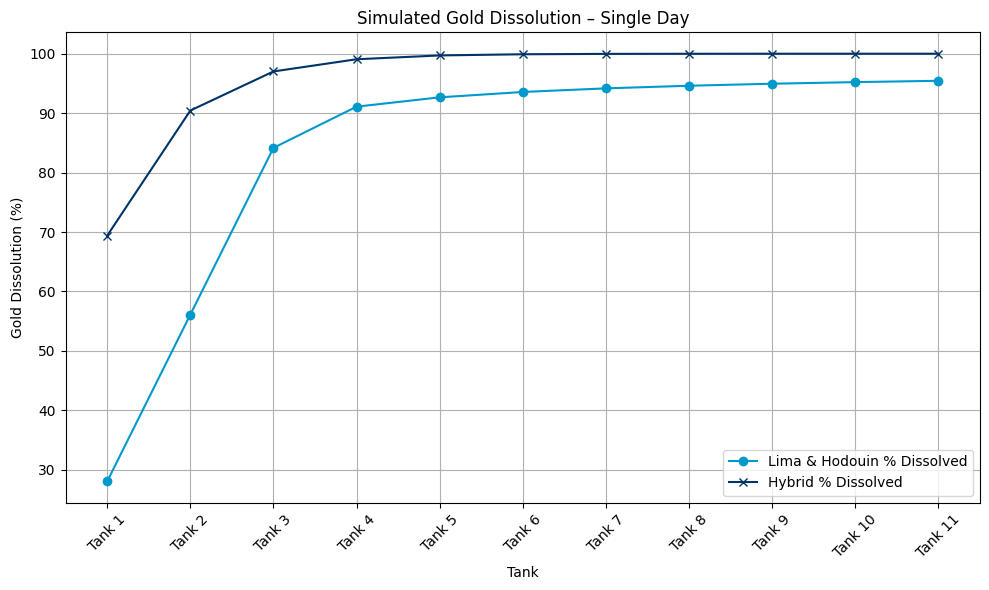

In [20]:
plot_line_dual(lh_pct, hybrid_pct, tanks,
				col1_label="Lima & Hodouin % Dissolved",
				col2_label="Hybrid % Dissolved",
				x_title="Tank", y_title="Gold Dissolution (%)",
				title="Simulated Gold Dissolution – Single Day")

### 📊 3.3 Plot Monthly Comparison Panels

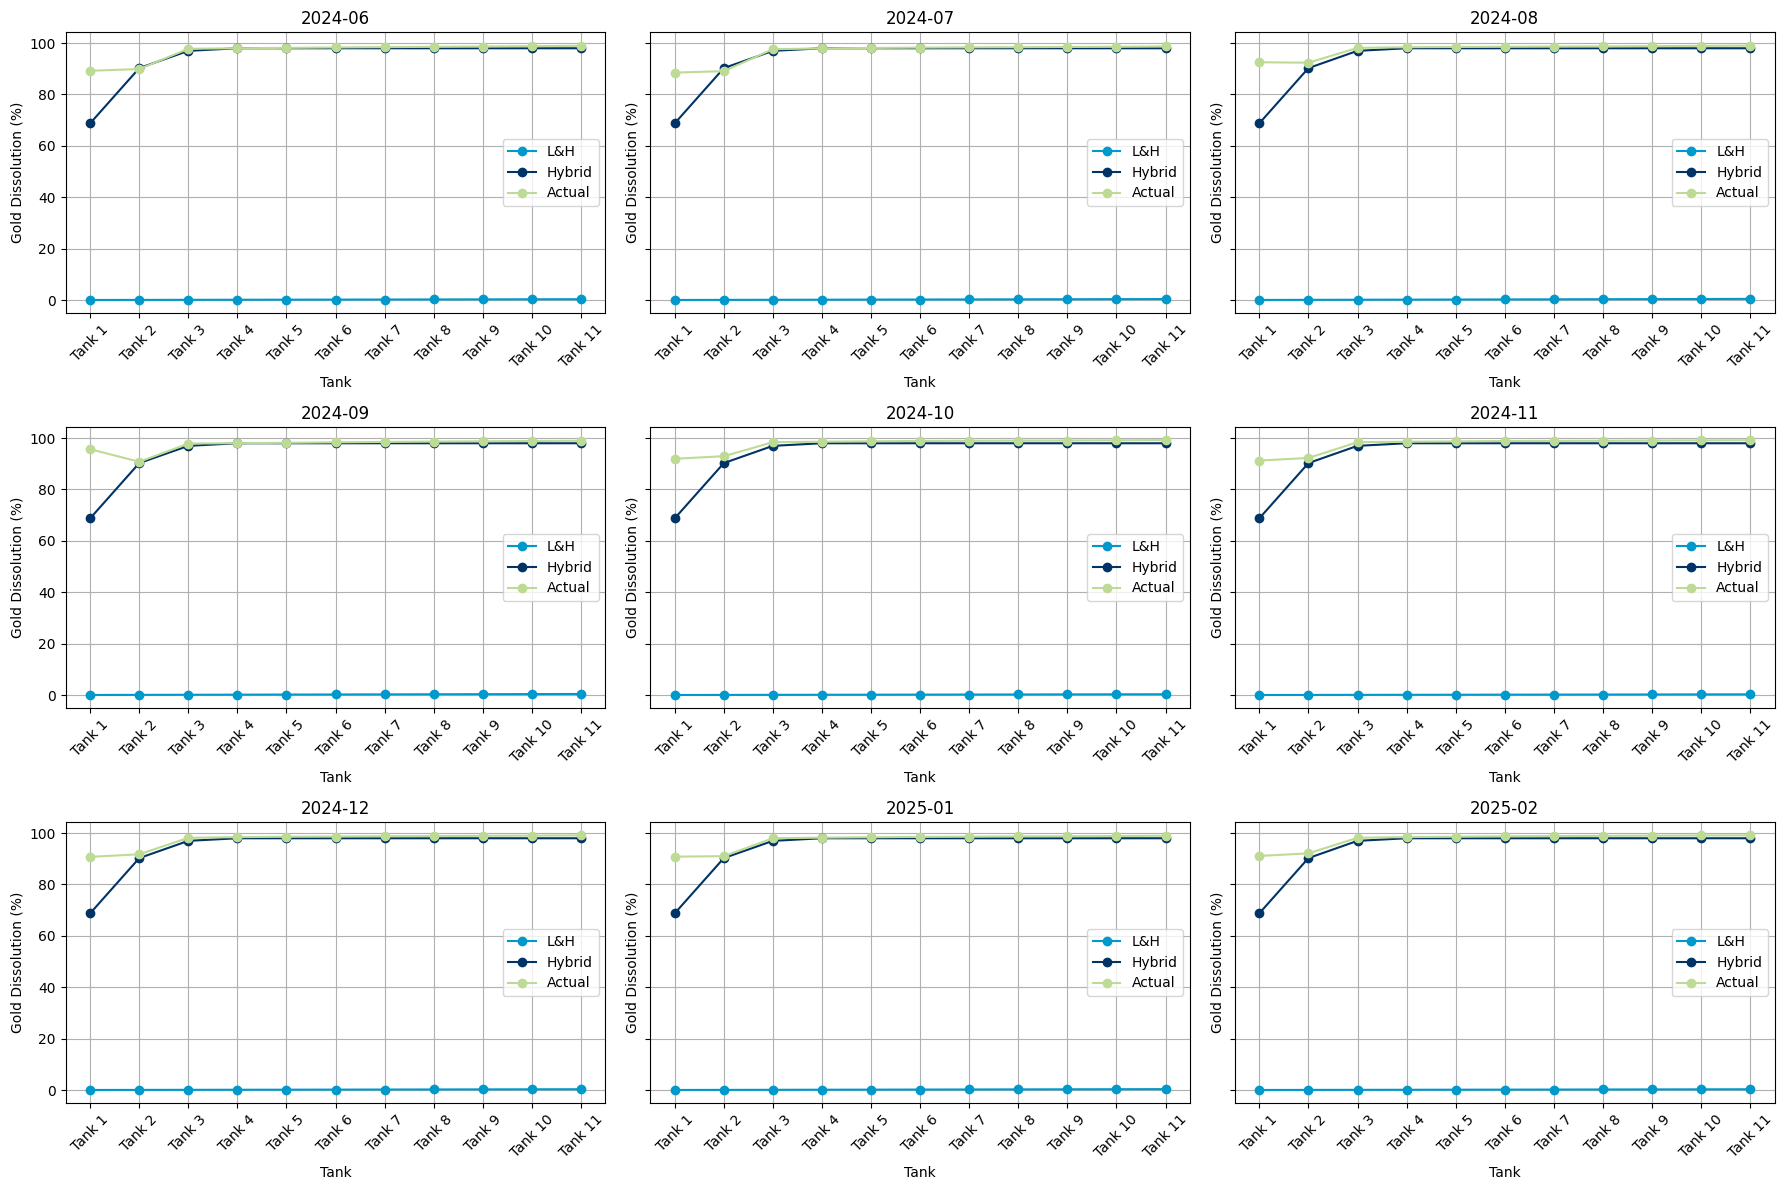

In [21]:
def plot_monthly_dissolution_comparison(df, group_by="Month"):

	# Assign month
	df[group_by] = pd.to_datetime(df["Date"]).dt.to_period("M")
	grouped = df.groupby(group_by)

	def run_models(adjusted_feed, locked_gold_floor, avg_feed_grade, CN, O2, d, n_tanks=11):
		t = total_residence_time / n_tanks
		tanks = [f"Tank {i+1}" for i in range(n_tanks)]
		
		# Lima & Hodouin
		au_lh = adjusted_feed
		pred_lh = []
		for _ in tanks:
			rate = lima_hodouin_dissolution(au_lh, locked_gold_floor, CN, O2, d)
			delta = min(rate * t, au_lh)
			au_lh = max(au_lh - delta, locked_gold_floor)
			pct = (adjusted_feed - au_lh) / avg_feed_grade * 100
			pred_lh.append(pct)

		# Hybrid
		au_hybrid = adjusted_feed
		pred_hybrid = []
		for i, _ in enumerate(tanks):
			if i in [0, 1]:  # Pre-leach tanks
				t_effective = t * 1  # or even 2.0, depending on residence logic
			else:
				t_effective = t
			au_hybrid = max(hybrid_dissolution(d, t_effective, au_hybrid), locked_gold_floor)
			pct = (adjusted_feed - au_hybrid) / adjusted_feed * 100
			pred_hybrid.append(pct)

		return tanks, pred_lh, pred_hybrid

	n_months = len(grouped)
	ncols = 3
	nrows = int(np.ceil(n_months / ncols))
	fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=True)
	axes = axes.flatten()

	for i, (month, group) in enumerate(grouped):
		tank_cols = [col for col in group.columns if "Undissolved_Gold" in col and "Grams_Per_Day" in col]
		grams_per_day = group[tank_cols].mean().values
		n_tanks = len(grams_per_day)

		avg_feed_grade = group["Leach_Feed_Grade_Au_Gt_Day"].mean() * 1000
		avg_milled = group["Daily_Milledtreated_Tons"].mean()
		total_gold_fed = (avg_feed_grade / 1e6) * avg_milled * 1e3
		adjusted_feed = avg_feed_grade * liberation_fraction

		locked_gold_floor = avg_feed_grade * locked_gold_threshold
		percent_solids = group["Percentsolids"].mean()
		CN = group["CN_ppm"].mean()
		O2 = group["O2_ppm"].mean()

		au_undissolved_mgkg = (grams_per_day / total_gold_fed) * avg_feed_grade
		actual_pct = (adjusted_feed - au_undissolved_mgkg) / adjusted_feed * 100

		tanks, pred_lh, pred_hybrid = run_models(adjusted_feed,
										   locked_gold_floor,
										   avg_feed_grade,
										   CN, O2, d, n_tanks)

		ax = axes[i]
		# ax.plot(tanks, pred_lh, label="L&H", marker='o')
		ax.plot(tanks, pred_hybrid, label="Hybrid", marker='x')
		ax.plot(tanks, actual_pct, label="Actual", marker='s')
		ax.set_title(str(month))
		ax.set_xlabel("Tank")
		ax.set_ylabel("Gold Dissolution (%)")
		ax.set_xticks(range(len(tanks)))
		ax.set_xticklabels(tanks, rotation=45)
		ax.grid(True)
		ax.legend()

	for j in range(i + 1, len(axes)):
		fig.delaxes(axes[j])

	plt.tight_layout()
	plt.show()

def generate_dissolution_lines(group):
	tank_cols = [col for col in group.columns if "Undissolved_Gold" in col and "Grams_Per_Day" in col]
	grams_per_day = group[tank_cols].mean().values
	n_tanks = len(grams_per_day)

	avg_feed_grade = group["Leach_Feed_Grade_Au_Gt_Day"].mean() * 1000  # g/t → mg/kg
	avg_milled = group["Daily_Milledtreated_Tons"].mean()
	total_gold_fed = (avg_feed_grade / 1e6) * avg_milled * 1e3  # t × mg/kg → grams
	adjusted_feed = avg_feed_grade * liberation_fraction
	locked_gold_floor = avg_feed_grade * locked_gold_threshold
	percent_solids = group["Percentsolids"].mean()
	CN = group["CN_ppm"].mean()
	O2 = group["O2_ppm"].mean()

	# Convert grams per day → mg/kg
	au_undissolved_mgkg = (grams_per_day / total_gold_fed) * avg_feed_grade
	actual_pct = (adjusted_feed - au_undissolved_mgkg) / adjusted_feed * 100

	def run_models(adjusted_feed, locked_gold_floor, avg_feed_grade, CN, O2, d, n_tanks=11):
		t = total_residence_time / n_tanks
		tanks = [f"Tank {i+1}" for i in range(n_tanks)]

		# L&H model
		au_lh = adjusted_feed
		pred_lh = []
		for _ in tanks:
			rate = lima_hodouin_dissolution(au_lh, locked_gold_floor, CN, O2, d)
			delta = min(rate * t, au_lh)
			au_lh = max(au_lh - delta, locked_gold_floor)
			pct = (adjusted_feed - au_lh) / avg_feed_grade * 100
			pred_lh.append(pct)

		# Hybrid model
		au_hybrid = adjusted_feed
		pred_hybrid = []
		for i, _ in enumerate(tanks):
			t_effective = t if i >= 2 else t * 1  # pre-leach can be doubled if desired
			au_hybrid = max(hybrid_dissolution(d, t_effective, au_hybrid), locked_gold_floor)
			pct = (adjusted_feed - au_hybrid) / adjusted_feed * 100
			pred_hybrid.append(pct)

		return tanks, pred_lh, pred_hybrid

	tanks, pred_lh, pred_hybrid = run_models(
		adjusted_feed,
		locked_gold_floor,
		avg_feed_grade,
		CN, O2, d,
		n_tanks=n_tanks
	)

	return tanks, {
		"L&H": pred_lh,
		"Hybrid": pred_hybrid,
		"Actual": actual_pct
	}


plot_grouped_dual_line_comparison(
	df=df_train,
	group_by="Month",
	generate_lines_fn=generate_dissolution_lines,
	ylabel="Gold Dissolution (%)",
	xlabel="Tank",
)


# Section 2: Develop a Cyanide Consumption Model

## Step 1: Calculate total cyanide entering and exiting the system

In [22]:
df_cn = df_site_cleaned.copy()

### Plot Daily Estimated CN Consumption vs Milled & Treated tonnes
* `Cn_Consumed_Kg_Estimate` derived during the Cleanse step

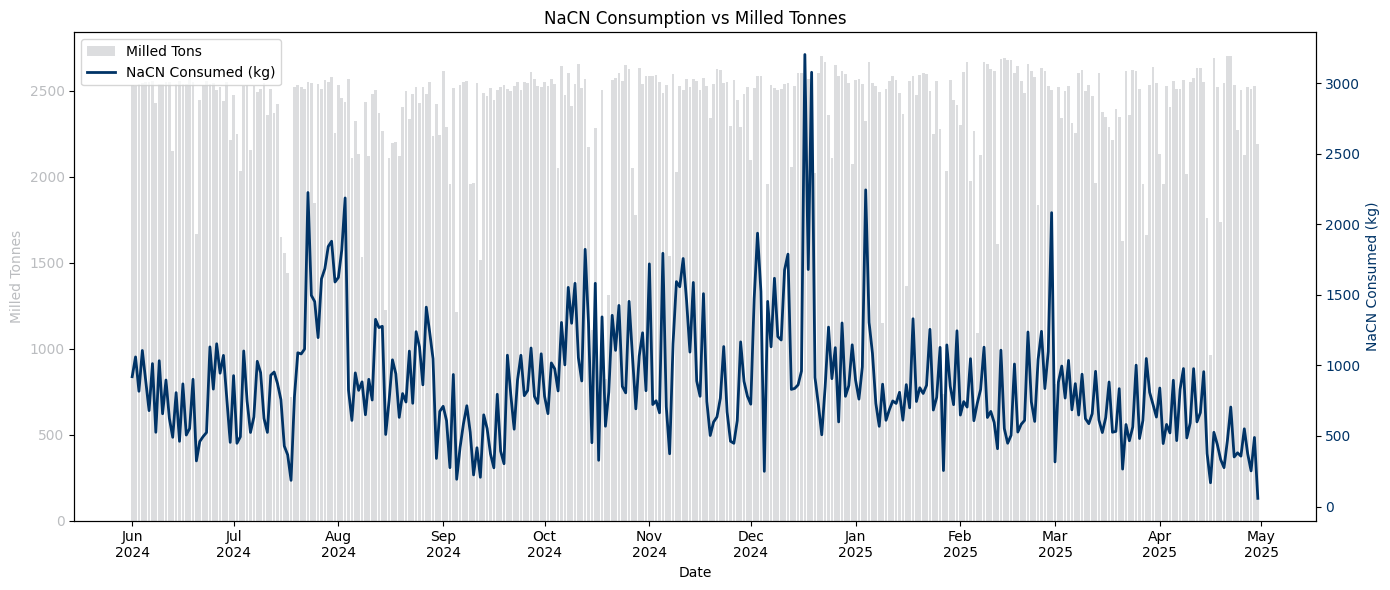

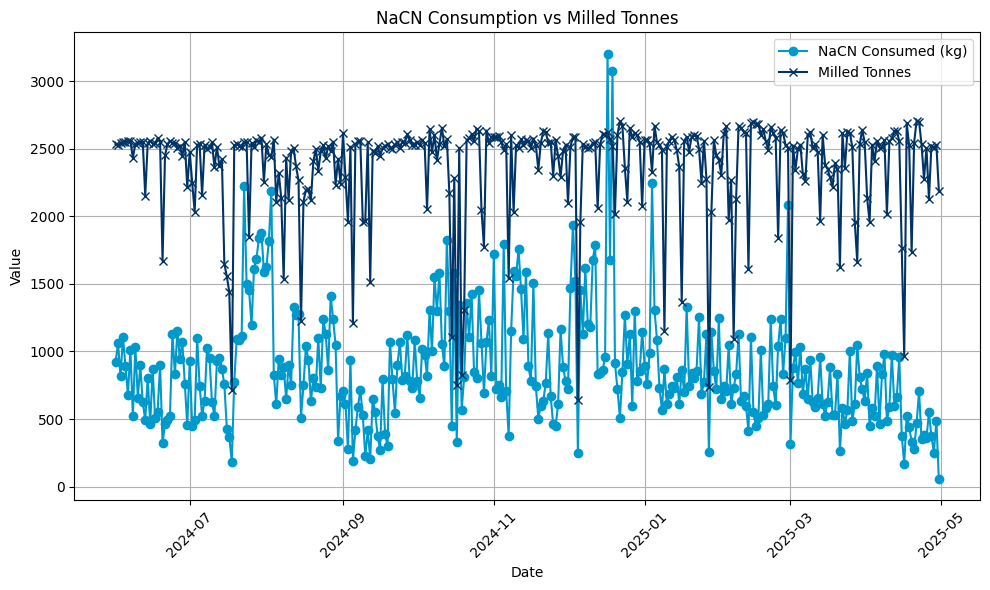

In [23]:
plot_dual_axis_bar_line(
	df=df_cn,
	x_col="Date",
	bar_col="Daily_Milledtreated_Tons",
	line_col="Cn_Consumed_Kg_Estimate",
	bar_label="Milled Tons",
	line_label="NaCN Consumed (kg)",
	x_label="Date",
	y1_label="Milled Tonnes",
	y2_label="NaCN Consumed (kg)",
	title="NaCN Consumption vs Milled Tonnes"
)

# Plot the same plot on a dual line plot
plot_line_dual(
	df_cn["Cn_Consumed_Kg_Estimate"],
	df_cn["Daily_Milledtreated_Tons"],
	df_cn["Date"],
	col1_label="NaCN Consumed (kg)",
	col2_label="Milled Tonnes",
	x_title="Date",
	y_title="Value",
	title="NaCN Consumption vs Milled Tonnes"
)


### Summary
* High levels of variation
* Check performance

### Derive actual daily ussage using recorded daily inventory withdrawls as basis of calculation

In [24]:
# Calculate NaCN used in kg based on Daily NaCN Used T values capped at defined ceiling
df_cn["NaCN_Used_kg"] = df_cn["Nacn_Used_T"].clip(lower=0, upper=max_nacn_drawdown) * 1000

# Back-calculate implied CN dosage in ppm
df_cn["Implied_CN_ppm"] = (
	df_cn["NaCN_Used_kg"] * 1e6 /
	(df_cn["Leach_Feed_Throughput_M3Day"] * pulp_density * 1000)
)

# Monthly average implied dosage (ppm)
monthly_avg_dosage_ppm = df_cn.groupby("Month")["Implied_CN_ppm"].mean().round(1)

# Monthly actual usage (t)
monthly_actual_cn_tonnes = df_cn.groupby("Month")["NaCN_Used_kg"].sum() / 1000

# Create summary table
df_dosage_summary = pd.DataFrame({
	"Avg_Implied_Dosage_ppm": monthly_avg_dosage_ppm,
	"NaCN_Used_t": monthly_actual_cn_tonnes
})

df_dosage_summary

,Avg_Implied_Dosage_ppm,NaCN_Used_t
Month,,
2024-06,296.9,45.000
2024-07,298.2,46.000
2024-08,216.6,41.000
2024-09,235.1,36.000
2024-10,313.1,52.000
2024-11,287.4,44.000
2024-12,418.6,63.000
2025-01,339.8,42.000
2025-02,243.1,34.290


### Interpretation
* December 2024 looks too high
* April 2025 looks too low

## Treat anomalies then re-summarise

In [25]:
# --- DECEMBER 19 SPIKE ADJUSTMENT ---
# Find original Dec 19 value
dec19_idx = df_cn[df_cn["Date"] == "2024-12-19"].index[0]
excess_dec19 = df_cn.loc[dec19_idx, "Nacn_Used_T"] - max_nacn_drawdown

# Cap Dec 19 to 6t
df_cn.loc[dec19_idx, "Nacn_Used_T"] = 6

# --- APRIL 14–22 GAP IMPUTATION ---
# Get average daily usage in April (excluding gap)
april_mask = (df_cn["Date"].dt.to_period("M") == "2025-04") & ~df_cn["Date"].between("2025-04-14", "2025-04-22")
april_avg = df_cn.loc[april_mask, "Nacn_Used_T"].mean()

# Fill missing or zero values between April 14–22 with avg
april_gap_mask = df_cn["Date"].between("2025-04-14", "2025-04-22")
df_cn.loc[april_gap_mask & (df_cn["Nacn_Used_T"].isna() | (df_cn["Nacn_Used_T"] == 0)), "Nacn_Used_T"] = april_avg

# Recalculate downstream fields
df_cn["NaCN_Used_kg"] = df_cn["Nacn_Used_T"].clip(lower=0, upper=max_nacn_drawdown) * 1000
df_cn["Implied_CN_ppm"] = (
	df_cn["NaCN_Used_kg"] * 1e6 /
	(df_cn["Leach_Feed_Throughput_M3Day"] * pulp_density * 1000)
)

# Monthly summary post-adjustment
monthly_avg_dosage_ppm = df_cn.groupby("Month")["Implied_CN_ppm"].mean().round(1)
monthly_actual_cn_tonnes = df_cn.groupby("Month")["NaCN_Used_kg"].sum() / 1000
df_dosage_summary = pd.DataFrame({
	"Avg_Implied_Dosage_ppm": monthly_avg_dosage_ppm,
	"NaCN_Used_t": monthly_actual_cn_tonnes
})

df_dosage_summary


,Avg_Implied_Dosage_ppm,NaCN_Used_t
Month,,
2024-06,296.9,45.000
2024-07,298.2,46.000
2024-08,216.6,41.000
2024-09,235.1,36.000
2024-10,313.1,52.000
2024-11,287.4,44.000
2024-12,393.4,59.000
2025-01,339.8,42.000
2025-02,243.1,34.290


## Compare CN concentration in tailings with implied dosage
* **Assumption:** If tailings CN is high, dosing may be excessive or residence time insufficient

In [26]:
# Calculate daily CN tailings ppm
df_cn["Tailings_CN_ppm"] = df_cn["Cn_Conc_Tailing_Ppm"]

# Examine correlation between CN dosage and tailings CN
daily_corr = df_cn[["Implied_CN_ppm", "Tailings_CN_ppm"]].corr().iloc[0, 1]

# Aggregate monthly averages for comparison
monthly_correlation_df = df_cn.groupby("Month").agg({
	"Implied_CN_ppm": "mean",
	"Tailings_CN_ppm": "mean"
}).round(1)

monthly_correlation_df["Dosage_vs_Tailings_Corr"] = daily_corr  # single value, constant per row

monthly_correlation_df


,Implied_CN_ppm,Tailings_CN_ppm,Dosage_vs_Tailings_Corr
Month,,,
2024-06,296.9,225.9,-0.041337
2024-07,298.2,322.1,-0.041337
2024-08,216.6,401.7,-0.041337
2024-09,235.1,286.4,-0.041337
2024-10,313.1,213.1,-0.041337
2024-11,287.4,181.9,-0.041337
2024-12,393.4,173.2,-0.041337
2025-01,339.8,360.6,-0.041337
2025-02,243.1,294.6,-0.041337


### Interpretation
* Poor performance across the board, suggesting that there is currently no correlation between Implied CN dosage and Tailings concentration.

## Create linear regression model to better define a dosage function

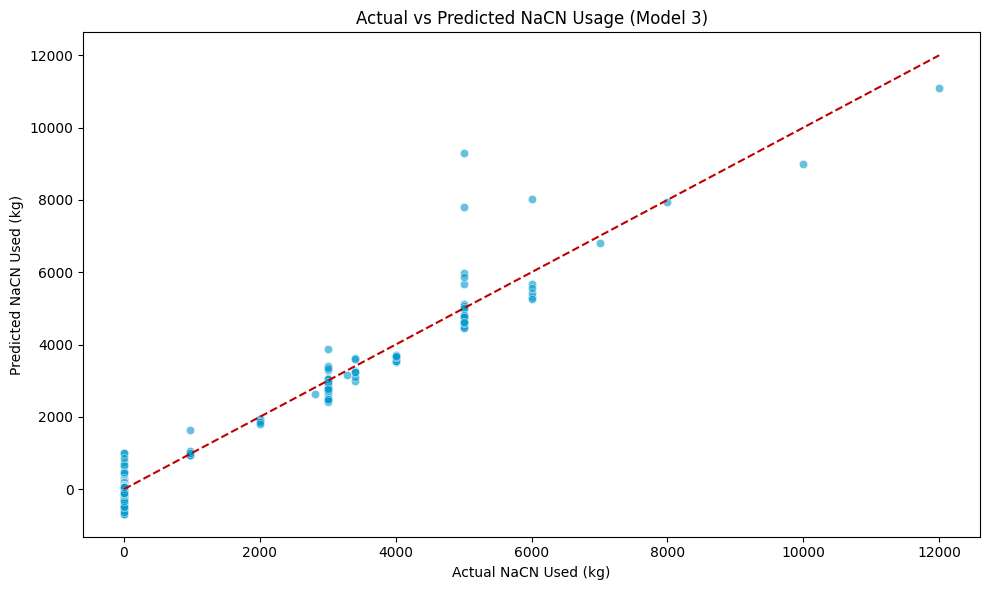

MAE: 227.15   RMSE: 412.31
Intercept: -1142.76


,Feature,Coefficient
0,Implied_CN_ppm,4.671586
1,Leach_Feed_Throughput_M3Day,0.316962
2,Leach_Feed_Grade_Au_Gt_Day,69.407769


In [27]:
# Create subset dropping N/A values form feature columns
df_3_feat = df_cn.dropna(subset=["NaCN_Used_kg", "Leach_Feed_Throughput_M3Day", "Leach_Feed_Grade_Au_Gt_Day"])

# Define X (CN ppm, feed m3/day, Au grade) and y (NaCN used)
X3 = df_3_feat[["Implied_CN_ppm", "Leach_Feed_Throughput_M3Day", "Leach_Feed_Grade_Au_Gt_Day"]]
y = df_3_feat["NaCN_Used_kg"]

# Fit linear regression model
model_3 = LinearRegression()
model_3.fit(X3, y)

# Predict and calculate residuals
df_3_feat["NaCN_Used_Model_3"] = model_3.predict(X3)
df_3_feat["Residual"] = df_3_feat["NaCN_Used_kg"] - df_3_feat["NaCN_Used_Model_3"]

mae_3 = mean_absolute_error(df_3_feat["NaCN_Used_kg"], df_3_feat["NaCN_Used_Model_3"])
rmse_3 = root_mean_squared_error(df_3_feat["NaCN_Used_kg"], df_3_feat["NaCN_Used_Model_3"])

# Display coefficients
coefficients_model_3 = pd.Series(model_3.coef_, index=X3.columns)
intercept_model_3 = model_3.intercept_

# Correct reset_index syntax for a Series
coefficients_model_3_df = coefficients_model_3.reset_index()
coefficients_model_3_df.columns = ["Feature", "Coefficient"]

# Plot actual vs predicted
plot_actual_vs_predicted_scatter(
	df=df_3_feat,
	actual_col="NaCN_Used_kg",
	predicted_col="NaCN_Used_Model_3",
	title="Actual vs Predicted NaCN Usage (Model 3)",
	x_label="Actual NaCN Used (kg)",
	y_label="Predicted NaCN Used (kg)"
)

print(f"MAE: {mae_3:.2f}   RMSE: {rmse_3:.2f}")
print(f"Intercept: {intercept_model_3:.2f}")
coefficients_model_3_df

### 📘 Regression-Based Cyanide Usage Estimation

The following equation was derived from a multiple linear regression model using plant data, where **daily cyanide usage** (in kg) was estimated as a function of:

- **Implied cyanide dosage** in solution (`Implied_CN_ppm`)
- **Leach feed throughput** in cubic metres per day (`Leach_Feed_Throughput_M3Day`)
- **Gold feed grade** in grams per tonne (`Leach_Feed_Grade_Au_Gt_Day`)

---

#### 📐 Regression Equation:

$$Estimated\;NaCN\;Used\;(kg) = A \cdot Implied\;CN\;ppm + B \cdot Leach\;Feed\;Throughput\;M^3\;\\Day + C \cdot Gold\;Grade + D$$

Where:
* $A = 4.671586$
* $B = 0.316962$
* $C = 69.407769$
* $D = -1142.7$

---

### 🧠 Interpretation:
- Each additional ppm of cyanide in solution increases expected usage by `~4.67` kg.
- Each extra cubic metre of feed adds `~0.32` kg.
- Each 1 g/t increase in gold grade increases usage by `~69.41` kg.
- The intercept (`−1143` kg) shifts the baseline and should only be interpreted within operational ranges.

This model enables **automated estimation** of daily NaCN requirements from key process variables and is suitable for benchmarking and anomaly detection.


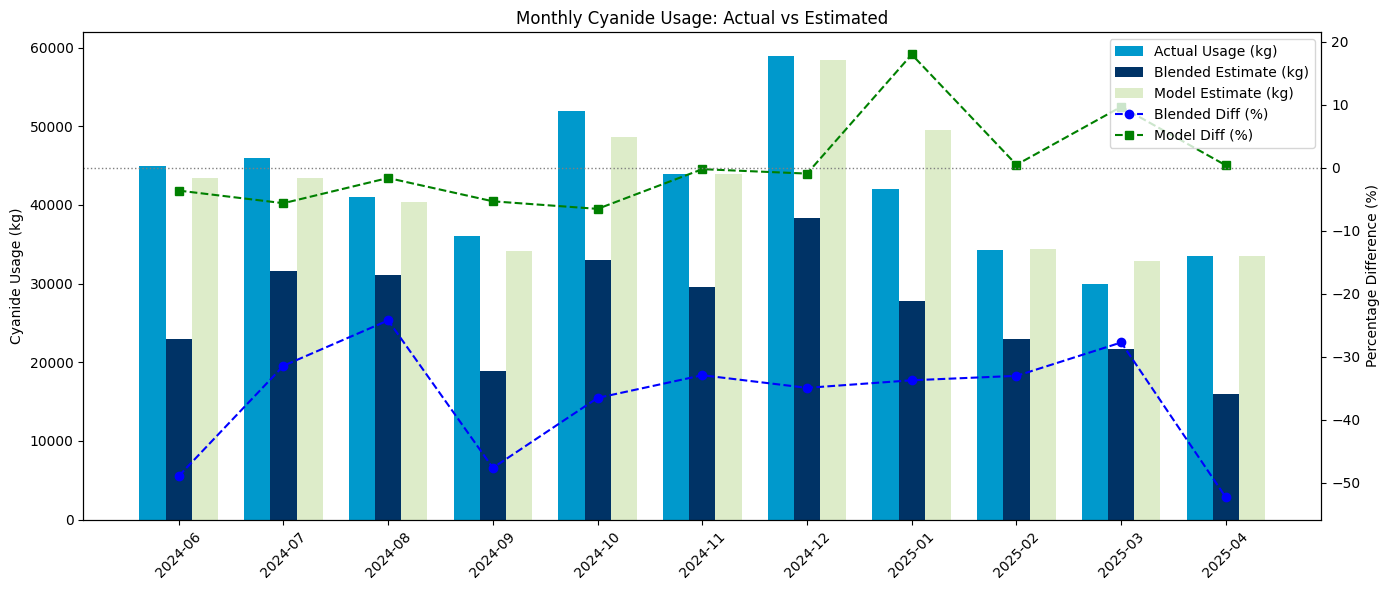

,Actual_Usage_kg,Blended_Estimate_kg,Model_3_Estimate_kg,Blended_Diff_%,Model_3_Diff_%
Month,,,,,
2024-06,45000.0,22976.0,43386.1,-48.9,-3.6
2024-07,46000.0,31550.4,43420.9,-31.4,-5.6
2024-08,41000.0,31088.8,40360.5,-24.2,-1.6
2024-09,36000.0,18870.9,34107.4,-47.6,-5.3
2024-10,52000.0,33019.5,48613.8,-36.5,-6.5
2024-11,44000.0,29528.2,43894.1,-32.9,-0.2
2024-12,59000.0,38393.2,58469.8,-34.9,-0.9
2025-01,42000.0,27848.5,49547.3,-33.7,18.0
2025-02,34290.0,22983.4,34446.0,-33.0,0.5


In [28]:
# Regression coefficients from Step 3
coef_cn_ppm = coefficients_model_3_df["Coefficient"][0]
coef_throughput = coefficients_model_3_df["Coefficient"][1]
coef_grade = coefficients_model_3_df["Coefficient"][2]
intercept = intercept_model_3

# Calculate estimated NaCN usage (kg/day) from the regression model
df_cn["NaCN_Used_Model_3"] = (
	coef_cn_ppm * df_cn["Implied_CN_ppm"] +
	coef_throughput * df_cn["Leach_Feed_Throughput_M3Day"] +
	coef_grade * df_cn["Leach_Feed_Grade_Au_Gt_Day"] +
	intercept
)

# Calculate residuals and percent error
df_cn["Model_3_Residual"] = df_cn["NaCN_Used_kg"] - df_cn["NaCN_Used_Model_3"]
df_cn["Model_3_Error_%"] = 100 * df_cn["Model_3_Residual"] / df_cn["NaCN_Used_kg"]

# Create a summary table comparing actual vs model-estimated NaCN usage (rounded to 2 decimal places)

df_comparison = df_cn[["Date", "NaCN_Used_kg", "NaCN_Used_Model_3"]].copy()
df_comparison["NaCN_Used_kg"] = df_cn["NaCN_Used_kg"].round(2)
df_cn["NaCN_Used_Model_3"] = df_cn["NaCN_Used_Model_3"].round(2)

# Export latest dataframe to CSV
df_cn.to_csv("updated_site_data.csv", index=False)

# Prepare monthly reconciliation
monthly_summary = df_cn.groupby("Month").agg({
	"NaCN_Used_kg": "sum",
	"Cn_Consumed_Kg_Estimate": "sum",
	"NaCN_Used_Model_3": "sum"
}).rename(columns={
	"NaCN_Used_kg": "Actual_Usage_kg",
	"Cn_Consumed_Kg_Estimate": "Blended_Estimate_kg",
	"NaCN_Used_Model_3": "Model_3_Estimate_kg"
})

# Calculate percentage differences
monthly_summary["Blended_Diff_%"] = 100 * (
	monthly_summary["Blended_Estimate_kg"] - monthly_summary["Actual_Usage_kg"]
) / monthly_summary["Actual_Usage_kg"]

monthly_summary["Model_3_Diff_%"] = 100 * (
	monthly_summary["Model_3_Estimate_kg"] - monthly_summary["Actual_Usage_kg"]
) / monthly_summary["Actual_Usage_kg"]

# Round and display
monthly_summary = monthly_summary.round(1)

# Plot bar chart of usage
plot_grouped_bar_with_secondary_lines(
	x_labels=monthly_summary.index.astype(str),
	bar_data=[
		monthly_summary["Actual_Usage_kg"],
		monthly_summary["Blended_Estimate_kg"],
		monthly_summary["Model_3_Estimate_kg"],
	],
	bar_labels=["Actual Usage (kg)", "Blended Estimate (kg)", "Model Estimate (kg)"],
	bar_alpha=[1.0, 1.0, 0.5],
	y1_label="Cyanide Usage (kg)",
	line_data=[
		monthly_summary["Blended_Diff_%"],
		monthly_summary["Model_3_Diff_%"],
	],
	line_labels=["Blended Diff (%)", "Model Diff (%)"],
	line_colours=["blue", "green"],
	y2_label="Percentage Difference (%)",
	title="Monthly Cyanide Usage: Actual vs Estimated",
)

monthly_summary

### **Key Insights:**
* Blue Bars (Actual): Show total NaCN drawn from inventory (capped at 6 t/day).
* Green Bars (Model Estimate): Track quite closely, especially June–December. Slight overshoot in Jan–Mar.
* Orange Bars (Blended Estimate): Consistently underestimate usage across all months by 24–52%.

Dashed Lines (Right Axis):
* 🔵 Blue: Blended estimate error (large negative values)
* 🟢 Green: Model estimate error (much smaller, some over/under-shoot)


| Method      | Error Trend         | Best Use Case                               |
| ----------- | ------------------- | ------------------------------------------- |
| **Blended** | Persistent underuse | Conservative baseline, fallback estimate    |
| **Model**   | Low, more balanced  | Benchmarking, forecast, diagnostic analysis |


## Extend Model with Increased Features
* Extend features to include dissolved oxygen and cyanide concentration in tailings

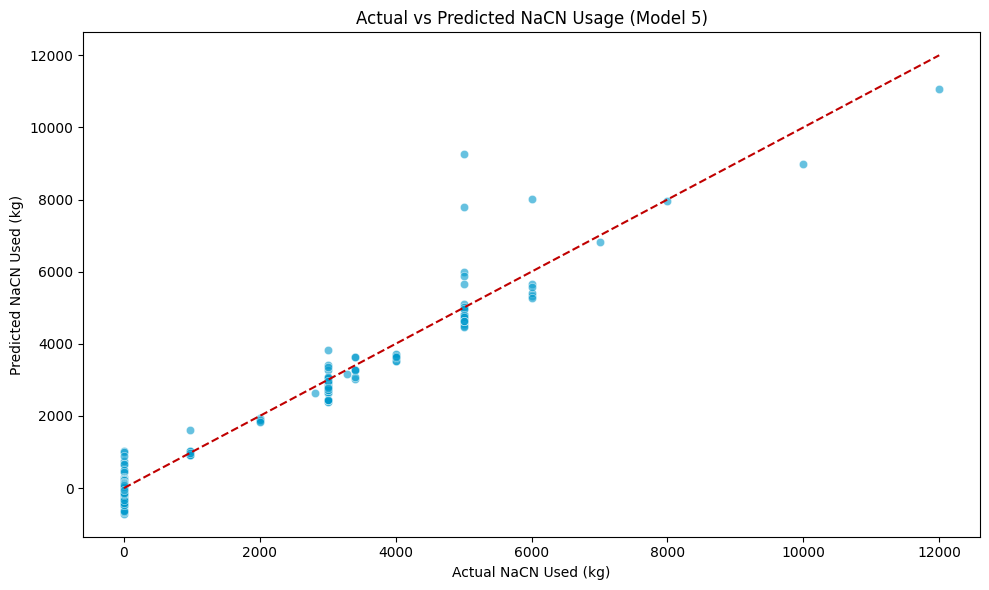

MAE: 227.63   RMSE: 411.56
Intercept: -1100.57


,Feature,Coefficient
0,Implied_CN_ppm,4.670711
1,Leach_Feed_Throughput_M3Day,0.314467
2,Leach_Feed_Grade_Au_Gt_Day,78.686572
3,Cn_Conc_Tailing_Ppm,0.130599
4,Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01,-4.994520


In [29]:
# Prepare extended regression with tailings CN and oxygen
df_5_feat = df_cn.dropna(subset=[
	"NaCN_Used_kg", "Implied_CN_ppm", "Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day", "Cn_Conc_Tailing_Ppm", "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
])

X5 = df_5_feat[[
	"Implied_CN_ppm",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Cn_Conc_Tailing_Ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
]]

# Fit extended model
model_5 = LinearRegression()
model_5.fit(X5, y)

# Predict and calculate diagnostics
df_5_feat["NaCN_Used_Model_5"] = model_5.predict(X5)
df_5_feat["Residual_Model_5"] = df_5_feat["NaCN_Used_kg"] - df_5_feat["NaCN_Used_Model_5"]

mae_5 = mean_absolute_error(df_5_feat["NaCN_Used_kg"], df_5_feat["NaCN_Used_Model_5"])
rmse_5 = root_mean_squared_error(df_5_feat["NaCN_Used_kg"], df_5_feat["NaCN_Used_Model_5"])

# Extract coefficients
coefficients_model_5 = pd.Series(model_5.coef_, index=X5.columns)
intercept_model_5 = model_5.intercept_

# Correct reset_index syntax for a Series
coefficients_model_5_df = coefficients_model_5.reset_index()
coefficients_model_5_df.columns = ["Feature", "Coefficient"]

# Define coefficients from 5-feature modelling
coef_cn_ppm = coefficients_model_5_df["Coefficient"][0]
coef_throughput = coefficients_model_5_df["Coefficient"][1]
coef_grade = coefficients_model_5_df["Coefficient"][2]
coef_tailings = coefficients_model_5_df["Coefficient"][3]
coef_o2 = coefficients_model_5_df["Coefficient"][4]
intercept = intercept_model_5

# Calculate estimated NaCN usage (kg/day) from the regression model
df_cn["NaCN_Used_Model_5"] = (
	coef_cn_ppm * df_cn["Implied_CN_ppm"] +
	coef_throughput * df_cn["Leach_Feed_Throughput_M3Day"] +
	coef_grade * df_cn["Leach_Feed_Grade_Au_Gt_Day"] +
	coef_tailings * df_cn["Cn_Conc_Tailing_Ppm"] +
	coef_o2 * df_cn["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"] +
	intercept
)

# Plot actual vs predicted
plot_actual_vs_predicted_scatter(
	df=df_5_feat,
	actual_col="NaCN_Used_kg",
	predicted_col="NaCN_Used_Model_5",
	title="Actual vs Predicted NaCN Usage (Model 5)",
	x_label="Actual NaCN Used (kg)",
	y_label="Predicted NaCN Used (kg)"
)


print(f"MAE: {mae_5:.2f}   RMSE: {rmse_5:.2f}")
print(f"Intercept: {intercept_model_5:.2f}")
coefficients_model_5_df

### **Key Insights:**
* Both models perform relatively well, within 0 -6.5% error range.
* Ideal for daily and monthly forecasting, benchmarking, or flagging anomalies.
* Not as nuanced as the enhanced (5-variable) model, but very practical and portable.

In [30]:
# Export updated dataframe to CSV
df_cn.to_csv("updated_site_data.csv", index=False)

### Fit Model without Implied CN as feature


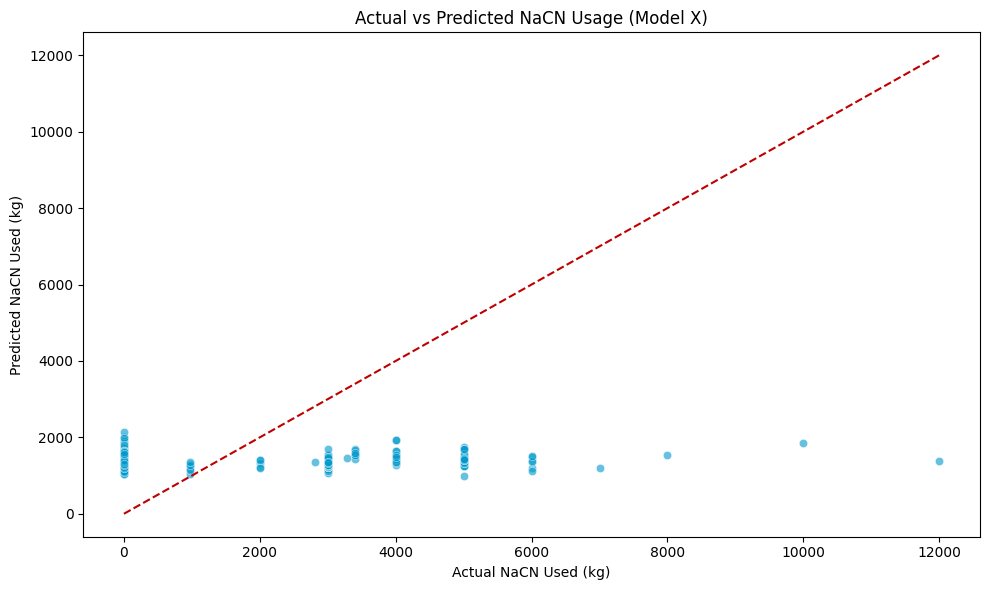

MAE: 1753.14   RMSE: 2036.82
Intercept: 1067.18


,Feature,Coefficient
0,Leach_Feed_Throughput_M3Day,0.112043
1,Leach_Feed_Grade_Au_Gt_Day,219.004294
2,Cn_Conc_Tailing_Ppm,-0.145466
3,Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01,-27.296032


In [31]:
# Prepare extended regression with tailings CN and oxygen
df_no_implied = df_cn.dropna(subset=[
	"NaCN_Used_kg", "Implied_CN_ppm", "Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day", "Cn_Conc_Tailing_Ppm", "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
])

XX = df_no_implied[[
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Cn_Conc_Tailing_Ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
]]

# Fit extended model
model_X = LinearRegression()
model_X.fit(XX, y)

# Predict and calculate diagnostics
df_no_implied["NaCN_Used_Model_X"] = model_X.predict(XX)
df_no_implied["NaCN_Residual_Model_X"] = df_no_implied["NaCN_Used_kg"] - df_no_implied["NaCN_Used_Model_X"]

mae_X = mean_absolute_error(df_no_implied["NaCN_Used_kg"], df_no_implied["NaCN_Used_Model_X"])
rmse_X = root_mean_squared_error(df_no_implied["NaCN_Used_kg"], df_no_implied["NaCN_Used_Model_X"])


# Extract coefficients
coefficients_model_X = pd.Series(model_X.coef_, index=XX.columns)
intercept_model_X = model_X.intercept_

# Correct reset_index syntax for a Series
coefficients_model_X_df = coefficients_model_X.reset_index()
coefficients_model_X_df.columns = ["Feature", "Coefficient"]


# Safe unpacking
coef_throughput = coefficients_model_X["Leach_Feed_Throughput_M3Day"]
coef_grade = coefficients_model_X["Leach_Feed_Grade_Au_Gt_Day"]
coef_tailings = coefficients_model_X["Cn_Conc_Tailing_Ppm"]
coef_o2 = coefficients_model_X["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"]
intercept = intercept_model_X


# Calculate estimated NaCN usage (kg/day) from the regression model
df_cn["NaCN_Used_Model_X"] = (
	coef_throughput * df_cn["Leach_Feed_Throughput_M3Day"] +
	coef_grade * df_cn["Leach_Feed_Grade_Au_Gt_Day"] +
	coef_tailings * df_cn["Cn_Conc_Tailing_Ppm"] +
	coef_o2 * df_cn["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"] +
	intercept
)

# Plot actual vs predicted
plot_actual_vs_predicted_scatter(
	df=df_no_implied,
	actual_col="NaCN_Used_kg",
	predicted_col="NaCN_Used_Model_X",
	title="Actual vs Predicted NaCN Usage (Model X)",
	x_label="Actual NaCN Used (kg)",
	y_label="Predicted NaCN Used (kg)"
)

print(f"MAE: {mae_X:.2f}   RMSE: {rmse_X:.2f}")
print(f"Intercept: {intercept_model_X:.2f}")
coefficients_model_X_df

## Compare 3-Feature vs 5-Feature vs Blended vs No Implied CN Estimates

In [32]:
# Group by month to summarise actual vs new estimate
df_cn["Month"] = pd.to_datetime(df_cn["Date"]).dt.to_period("M")
monthly_regression = df_cn.groupby("Month").agg({
	"NaCN_Used_kg": "sum",
	"NaCN_Used_Model_3": "sum",
	"NaCN_Used_Model_5": "sum",
	"NaCN_Used_Model_X": "sum"
}).rename(columns={
	"NaCN_Used_kg": "Actual_Usage_kg",
	"NaCN_Used_Model_3": "Estimate_Model_3_Usage_kg",
	"NaCN_Used_Model_5": "Estimate_Model_5_Usage_kg",
	"NaCN_Used_Model_X": "Estimate_Model_X_Usage_kg"
})

# Calculate % differences
monthly_regression["Delta_Model_3%"] = 100 * (
	monthly_regression["Estimate_Model_3_Usage_kg"] - monthly_regression["Actual_Usage_kg"]
) / monthly_regression["Actual_Usage_kg"]

monthly_regression["Delta_Model_5%"] = 100 * (
	monthly_regression["Estimate_Model_5_Usage_kg"] - monthly_regression["Actual_Usage_kg"]
) / monthly_regression["Actual_Usage_kg"]

monthly_regression["Delta_Model_X%"] = 100 * (
	monthly_regression["Estimate_Model_X_Usage_kg"] - monthly_regression["Actual_Usage_kg"]
) / monthly_regression["Actual_Usage_kg"]

# Round and display
monthly_regression = monthly_regression.round(1)

print("Monthly CN Usage – 3 & 5-Variable Models along with No Implied CN Model")
monthly_regression


Monthly CN Usage – 3 & 5-Variable Models along with No Implied CN Model


,Actual_Usage_kg,Estimate_Model_3_Usage_kg,Estimate_Model_5_Usage_kg,Estimate_Model_X_Usage_kg,Delta_Model_3%,Delta_Model_5%,Delta_Model_X%
Month,,,,,,,
2024-06,45000.0,43386.1,42913.3,40719.1,-3.6,-4.6,-9.5
2024-07,46000.0,43420.9,43193.2,38753.9,-5.6,-6.1,-15.8
2024-08,41000.0,40360.5,40705.2,42020.5,-1.6,-0.7,2.5
2024-09,36000.0,34107.4,33914.9,38347.6,-5.3,-5.8,6.5
2024-10,52000.0,48613.8,48825.2,47255.6,-6.5,-6.1,-9.1
2024-11,44000.0,43894.1,43688.0,45670.1,-0.2,-0.7,3.8
2024-12,59000.0,58469.8,58118.1,44368.1,-0.9,-1.5,-24.8
2025-01,42000.0,49547.3,49574.9,39890.4,18.0,18.0,-5.0
2025-02,34290.0,34446.0,34565.5,40285.0,0.5,0.8,17.5


### 🎯 1. Descriptive or Diagnostic Modelling
* **Goal:** Understand the key drivers behind historical cyanide usage.
* **Inputs:** Can include things like Implied_CN_ppm, even if they’re derived post-hoc.
* **Use case:** Root cause analysis, operator training, benchmarking.
* **Suitable models:** Linear regression, SHAP analysis, statistical summaries.
* **Limitations:** Not suitable for real-time or predictive control.

### 🔁 Next Steps:
* SHAP or feature importance plots to visually prioritise key drivers.
* Anomaly tagging for periods where actual usage deviated significantly from model.

C:\Users\expg\AppData\Local\Temp\ipykernel_24700\3542746375.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")


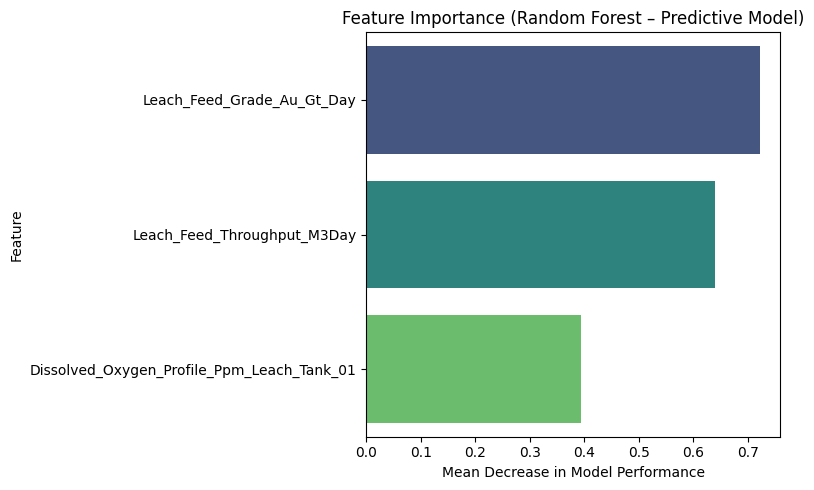

(                                      Feature  Importance
 1                  Leach_Feed_Grade_Au_Gt_Day       0.723
 0                 Leach_Feed_Throughput_M3Day       0.640
 2  Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01       0.393,
 0.8016837868528712,
 np.float64(707.3053304904051))

In [33]:
# Define features that could be available in real-time
features_real_time = [
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01",
]

# Drop rows with missing values in these columns
df_model = df_cn.dropna(subset=features_real_time + ["NaCN_Used_kg"])

X = df_model[features_real_time]
y = df_model["NaCN_Used_kg"]

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Calculate permutation importance
result = permutation_importance(rf_model, X, y, n_repeats=10, random_state=42)
importance_df = pd.DataFrame({
	"Feature": features_real_time,
	"Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance (Random Forest – Predictive Model)")
plt.xlabel("Mean Decrease in Model Performance")
plt.tight_layout()
plt.show()

# Step 2: Predictive Model – Exclude Implied CN PPM and Tailings
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

# Step 3: Prescriptive Calculator Prototype
# We'll define a dose recommender using a simple linear formula for now
def recommend_cn_dose(feed_throughput, feed_grade, o2_ppm, coef=[0.3, 50, 0.1], intercept=200):
	"""Recommend CN dosage ppm based on real-time values."""
	return (
		coef[0] * feed_throughput +
		coef[1] * feed_grade +
		coef[2] * o2_ppm +
		intercept
	)

# Apply to a new column for demonstration
df_cn["CN_Dose_Recommended_ppm"] = df_cn.apply(
	lambda row: recommend_cn_dose(
		row["Leach_Feed_Throughput_M3Day"],
		row["Leach_Feed_Grade_Au_Gt_Day"],
		row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"]
	) if pd.notnull(row["Leach_Feed_Throughput_M3Day"]) and pd.notnull(row["Leach_Feed_Grade_Au_Gt_Day"]) and pd.notnull(row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"]) else np.nan,
	axis=1
)



df_cn[["Date", "CN_Dose_Recommended_ppm"] + features_real_time + ["NaCN_Used_kg"]].dropna()

importance_df.round(3), rf_r2, rf_mae

### Feature Importance (Random Forest – Descriptive Insight)

| Feature                                              | Importance |
| ---------------------------------------------------- | ---------: |
| **Leach\_Feed\_Grade\_Au\_Gt\_Day**                  | 0.723      |
| **Leach\_Feed\_Throughput\_M3Day**                   | 0.649      |
| **Dissolved\_Oxygen\_Profile\_Ppm\_Leach\_Tank\_01** | 0.393      |

📈 Predictive Model (Excludes Implied CN PPM)
* **R² Score: $0.802$** (Good fit, given real-time only inputs)
* **MAE: ~$707$** kg/day (Reasonable for a process model)

🧮 Prescriptive Model (Prototype Equation)
This simple dose recommender (for operational use) uses the form:

$$CN\_ Dose \_ ppm=0.3×Throughput+50×Au Grade+0.1×Dissolved O_2 +200$$
Where:
* Throughput is in m³/day
* Grade is in g/t
* O₂ is in ppm


<Figure size 1200x600 with 0 Axes>

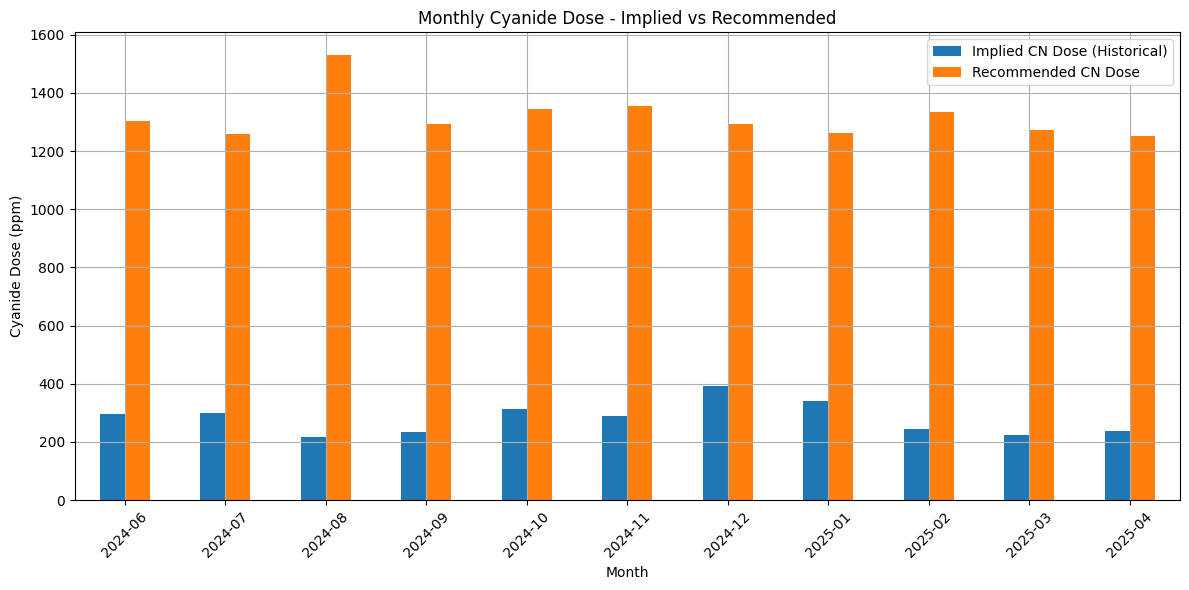

In [34]:
# Define initial coeffcients and intercept
coef_throughput = 0.3
coef_grade = 50
coef_o2 = 0.1
intercept = 200

# Calculate recommeded dose (ppm) using only operational inputs
df_cn["CN_Dose_Recommended_ppm"] = (
	coef_throughput * df_cn["Leach_Feed_Throughput_M3Day"] + 
	coef_grade * df_cn["Leach_Feed_Grade_Au_Gt_Day"] + 
	coef_o2 * df_cn["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"] + 
	intercept
)

# --- Validation: Comare Recommended Dose with Implied Dose
df_cn["Dose_Gap_ppm"] = df_cn["CN_Dose_Recommended_ppm"] - df_cn["Implied_CN_ppm"]

# Aggregate monthly statistics
monthly_dose_gap = df_cn.groupby("Month")[["Implied_CN_ppm", "CN_Dose_Recommended_ppm", "Dose_Gap_ppm"]].mean().round(1)

# --- Plot: Actual vs Recommended Dose Over Time
plt.figure(figsize=(12, 6))
monthly_dose_gap[["Implied_CN_ppm", "CN_Dose_Recommended_ppm"]].plot(kind="bar", figsize=(12, 6))
plt.title("Monthly Cyanide Dose - Implied vs Recommended")
plt.ylabel("Cyanide Dose (ppm)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.legend(["Implied CN Dose (Historical)", "Recommended CN Dose"])
plt.tight_layout()
plt.grid(True)
plt.show()

In [35]:
# Update initial coeffcients and intercept
coef_throughput = 0.3
coef_grade = 56
coef_o2 = 2.5
intercept = 100

# --- Predict NaCN Used (kg) using empirical model ---
df_cn["NaCN_Used_Estimated"] = (
	coef_throughput * df_cn["Leach_Feed_Throughput_M3Day"] + 
	coef_grade * df_cn["Leach_Feed_Grade_Au_Gt_Day"] + 
	coef_o2 * df_cn["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"] + 
	intercept
)

# --- Convert predicted usage to dosage (ppm) ---
df_cn["Dosage_Estimated_ppm"] = (
	df_cn["NaCN_Used_Estimated"] * 1e6 /
	(df_cn["Leach_Feed_Throughput_M3Day"] * pulp_density * 1000)
)

# --- Clip to avoid negative dosage estimates ---
df_cn["NaCN_Used_Estimated"] = df_cn["NaCN_Used_Estimated"].clip(lower=0)
df_cn["Dosage_Estimated_ppm"] = df_cn["Dosage_Estimated_ppm"].clip(lower=0)

# --- Monthly summary: Actual vs Estimated ---
monthly_summary = df_cn.groupby("Month").agg({
	"Implied_CN_ppm": "mean",
	"Dosage_Estimated_ppm": "mean"
}).rename(columns={
	"Implied_CN_ppm": "Actual_Dosage_ppm",
	"Dosage_Estimated_ppm": "Estimated_Dosage_ppm"
})

monthly_summary["Delta_%"] = 100 * (
	monthly_summary["Estimated_Dosage_ppm"] - monthly_summary["Actual_Dosage_ppm"]
) / monthly_summary["Actual_Dosage_ppm"]

monthly_summary = monthly_summary.round(1)
monthly_summary

,Actual_Dosage_ppm,Estimated_Dosage_ppm,Delta_%
Month,,,
2024-06,296.9,257.0,-13.4
2024-07,298.2,257.8,-13.5
2024-08,216.6,239.6,10.6
2024-09,235.1,250.9,6.7
2024-10,313.1,260.8,-16.7
2024-11,287.4,258.1,-10.2
2024-12,393.4,260.4,-33.8
2025-01,339.8,261.1,-23.2
2025-02,243.1,258.3,6.3


In [36]:
# Drop rows with missing values in key columns
df = df_cn.dropna(subset=[
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01",
	"Implied_CN_ppm"
])

# Define tuning ranges for throughput, grade, oxygen weights and intercept
throughput_weights = np.arange(0.1, 1.0, 0.1)
grade_weights = np.arange(10, 100, 10)
o2_weights = np.arange(0.0, 1.0, 0.1)
intercepts = np.arange(100, 500, 50)

# Perform grid search for best empirical coefficients
results = []

for w_throughput in throughput_weights:
	for w_grade in grade_weights:
		for w_o2 in o2_weights:
			for intercept in intercepts:
				df["Estimated_CN_ppm"] = (
					w_throughput * df["Leach_Feed_Throughput_M3Day"] +
					w_grade * df["Leach_Feed_Grade_Au_Gt_Day"] +
					w_o2 * df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"] +
					intercept
				)
				rmse = np.sqrt(root_mean_squared_error(df["Implied_CN_ppm"], df["Estimated_CN_ppm"]))
				mae = mean_absolute_error(df["Implied_CN_ppm"], df["Estimated_CN_ppm"])
				results.append({
					"w_throughput": w_throughput,
					"w_grade": w_grade,
					"w_o2": w_o2,
					"intercept": intercept,
					"RMSE": rmse,
					"MAE": mae
				})

# Return top parameter sets
df_results = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)

df_results

,w_throughput,w_grade,w_o2,intercept,RMSE,MAE
0,0.1,10,0.0,100,21.747603,417.054318
1,0.1,10,0.1,100,21.763449,417.748405
2,0.1,10,0.2,100,21.779425,418.442492
3,0.1,10,0.3,100,21.795528,419.136579
4,0.1,10,0.4,100,21.811759,419.830666
...,...,...,...,...,...,...
6475,0.9,90,0.5,450,59.003459,3398.394500
6476,0.9,90,0.6,450,59.018361,3400.185233
6477,0.9,90,0.7,450,59.033260,3401.975967
6478,0.9,90,0.8,450,59.048156,3403.766700


In [37]:
# --- Define features and target ---
features = [
	"Implied_CN_ppm",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Cn_Conc_Tailing_Ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
]
target = "NaCN_Used_kg"

# --- Drop missing values and define X, y ---
df_model = df_cn.dropna(subset=features + [target])
X = df_model[features]
y = df_model[target]
feature_names = X.columns.tolist()

# --- Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Cross-validation strategy ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Ridge Regression (CV to find best alpha) ---
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=cv)
ridge.fit(X_scaled, y)
ridge_scores = cross_val_score(ridge, X_scaled, y, cv=cv)

# --- Lasso Regression (CV to find best alpha) ---
lasso = LassoCV(alphas=np.logspace(-3, 1, 50), cv=cv, max_iter=10000)
lasso.fit(X_scaled, y)
lasso_scores = cross_val_score(lasso, X_scaled, y, cv=cv)

# --- Extract best alphas and mean scores ---
best_alpha_ridge = ridge.alpha_
best_alpha_lasso = lasso.alpha_

print(f"Best Ridge alpha: {best_alpha_ridge:.4f}, CV Score: {ridge_scores.mean():.4f}")
print(f"Best Lasso alpha: {best_alpha_lasso:.4f}, CV Score: {lasso_scores.mean():.4f}")

Best Ridge alpha: 1.5264, CV Score: 0.9563
Best Lasso alpha: 10.0000, CV Score: 0.9569


In [38]:
# Save dataframe to csv
df_cn.to_csv("updated_site_data.csv", index=False)

In [39]:
# --- Fit final models on scaled data using best alphas ---
ridge_final = Ridge(alpha=best_alpha_ridge)
ridge_final.fit(X_scaled, y)

lasso_final = Lasso(alpha=best_alpha_lasso)
lasso_final.fit(X_scaled, y)

# --- Extract coefficients into named Series ---
ridge_coefs = pd.Series(ridge_final.coef_, index=feature_names, name="Ridge Coefficients")
lasso_coefs = pd.Series(lasso_final.coef_, index=feature_names, name="Lasso Coefficients")

# --- Combine for side-by-side comparison ---
coef_comparison = pd.concat([ridge_coefs, lasso_coefs], axis=1).round(4)

# --- Display the coefficient table ---
print("Ridge vs Lasso Coefficient Comparison:")
display(coef_comparison)


Ridge vs Lasso Coefficient Comparison:


,Ridge Coefficients,Lasso Coefficients
Implied_CN_ppm,1994.9084,1993.9395
Leach_Feed_Throughput_M3Day,208.2523,198.6881
Leach_Feed_Grade_Au_Gt_Day,37.6242,22.4226
Cn_Conc_Tailing_Ppm,18.9315,3.8067
Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01,-18.7448,-9.1964


In [40]:
# Apply scaled Ridge model to full dataset for monthly analysis
df_model["NaCN_Used_Model_Ridge"] = ridge.predict(X_scaled)
df_model["NaCN_Used_Model_Lasso"] = lasso.predict(X_scaled)
# Convert 'Date' to datetime and extract month

# Group and analyse
monthly_summary_scaled = df_model.groupby("Month").agg({
	"NaCN_Used_kg": "sum",
	"NaCN_Used_Model_Ridge": "sum",
	"NaCN_Used_Model_Lasso": "sum"
}).rename(columns={
	"NaCN_Used_kg": "Actual_Usage_kg",
	"NaCN_Used_Model_Ridge": "Predicted_Ridge_Usage_kg",
	"NaCN_Used_Model_Lasso": "Predicted_Lasso_Usage_kg",
})
monthly_summary_scaled["Ridge_Absolute_Error_kg"] = (monthly_summary_scaled["Predicted_Ridge_Usage_kg"] - monthly_summary_scaled["Actual_Usage_kg"]).round(1)
monthly_summary_scaled["Ridge_Percent_Error_%"] = ((monthly_summary_scaled["Ridge_Absolute_Error_kg"] / monthly_summary_scaled["Actual_Usage_kg"]) * 100).round(1)
monthly_summary_scaled["Lasso_Absolute_Error_kg"] = (monthly_summary_scaled["Predicted_Lasso_Usage_kg"] - monthly_summary_scaled["Actual_Usage_kg"]).round(1)
monthly_summary_scaled["Lasso_Percent_Error_%"] = ((monthly_summary_scaled["Lasso_Absolute_Error_kg"] / monthly_summary_scaled["Actual_Usage_kg"]) * 100).round(1)
monthly_summary_scaled

# Optional: Export
monthly_summary_scaled.to_csv("monthly_cn_prediction_ridge_vs_actual.csv")

plt.figure(figsize=(12, 6))
monthly_summary_scaled[["Actual_Usage_kg", "Predicted_Usage_kg"]].plot(kind="bar", figsize=(14, 6))
plt.title("Monthly NaCN Usage: Actual vs Predicted (Ridge Regression)")
plt.ylabel("NaCN Used (kg)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

monthly_summary_scaled


KeyError: "['Predicted_Usage_kg'] not in index"

<Figure size 1200x600 with 0 Axes>

In [ ]:
# Drop rows with missing data in key fields
df_model = df_cn.dropna(subset=[
	"NaCN_Used_kg",
	"Implied_CN_ppm",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Cn_Conc_Tailing_Ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
])

# Define feature matrix X and target y
X = df_model[[
	"Implied_CN_ppm",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Cn_Conc_Tailing_Ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
]]
y = df_model["NaCN_Used_kg"]

# Confirm dimensions and head of input features
X.shape, y.shape, X.head()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42
)

# Fit linear regression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predict on test set
y_pred = linreg.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Extract coefficients
coefficients = pd.Series(linreg.coef_, index=X.columns)
intercept = linreg.intercept_

coefficients, intercept, mae, r2

# Monthly aggregation for actual and predicted usage
monthly_summary = df.groupby("Month").agg({
	"NaCN_Used_kg": "sum",
	"NaCN_Used_Model_5": "sum"
}).rename(columns={
	"NaCN_Used_kg": "Actual_Usage_kg",
	"NaCN_Used_Model_5": "Predicted_Usage_kg"
})

# Compute absolute and percentage difference
monthly_summary["Absolute_Error_kg"] = (monthly_summary["Predicted_Usage_kg"] - monthly_summary["Actual_Usage_kg"]).round(1)
monthly_summary["Percent_Error_%"] = ((monthly_summary["Absolute_Error_kg"] / monthly_summary["Actual_Usage_kg"]) * 100).round(1)

# Export to CSV
monthly_summary.to_csv("monthly_cn_prediction_vs_actual.csv")

plt.figure(figsize=(12, 6))
monthly_summary[["Actual_Usage_kg", "Predicted_Usage_kg"]].plot(kind="bar", figsize=(14, 6))
plt.title("Monthly NaCN Usage: Actual vs Predicted (5-Feature Linear Model)")
plt.ylabel("NaCN Used (kg)")
plt.xlabel("Month")
plt.xticks(rotation=45)	
plt.tight_layout()
plt.grid(True)

monthly_summary

plt.show()

### 🔮 2. Predictive (Forward-Looking) Modelling
* **Goal:** Predict how much cyanide will be required before it is dosed.
* **Inputs:** Must be available in advance (e.g. feed throughput, feed grade, dissolved oxygen).
* **Use case:** Forecasting cyanide needs for the next shift/day, real-time control.
* **Suitable models:** Regression, ML (e.g. XGBoost), time-series forecasting.
* **Requirements:**
	- Good quality lag features or predictive estimates of feed conditions.
	- Realistic constraints — e.g., avoiding future-leakage from outcome-based variables.

### 🔁 Next Steps:
* Construct a version of Model_5 excluding Implied_CN_ppm and tailings concentration.
* Compare performance (likely worse — but realistic).
* Optionally train ML models (RandomForest, XGBoost) for non-linear effects.

In [ ]:
import shap

# Drop rows with missing values in relevant columns
df_model = df_cn.dropna(subset=[
	"NaCN_Used_kg",
	"Leach_Feed_Throughput_M3Day",
	"Leach_Feed_Grade_Au_Gt_Day",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"
]).copy()

# Define features and target for real-time model
features = ["Leach_Feed_Throughput_M3Day", "Leach_Feed_Grade_Au_Gt_Day", "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"]
target = "NaCN_Used_kg"

X = df_model[features]
y = df_model[target]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Linear Regression Model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

# 2. Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Model evaluation metrics
metrics = {
	"Model": ["Linear Regression", "Random Forest"],
	"R2": [r2_score(y_test, y_pred_lin), r2_score(y_test, y_pred_rf)],
	"MAE": [mean_absolute_error(y_test, y_pred_lin), mean_absolute_error(y_test, y_pred_rf)],
	"RMSE": [np.sqrt(root_mean_squared_error(y_test, y_pred_lin)), np.sqrt(root_mean_squared_error(y_test, y_pred_rf))]
}

metrics_df = pd.DataFrame(metrics)

# SHAP for Random Forest
explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test, check_additivity=False)

# Visualise feature importance
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary_plot.png")

### ⚖️ 3. Prescriptive (Control or Optimisation) Modelling
* **Goal:** Recommend how much cyanide to dose to hit a desired recovery or tailings ppm.
* **Inputs:** Target tailings grade or recovery + current conditions (e.g. DO, feed tonnage).
* **Use case:** Dose control systems, what-if scenario modelling, closed-loop control.
* **Approach:** Inverse models, optimisers, hybrid simulations (e.g. LeachOpti).
* **Complexity:** Higher — requires calibration and integration with operational logic.

### 🔁 Next Steps:

Select a target outcome (e.g. Cn_Conc_Tailing_Ppm ≤ 0.3 ppm)

Build a dose-recommendation function using either:

Direct regression: Dose = f(feed, DO, target)

Simulation + optimiser: search CN ppm that hits target

In [41]:
df_residuals = df_site.copy()

# Step 1: Identify high-error periods (e.g., abs residual > 1000 kg)
df_residuals["High_Error"] = df_residuals["Model_Residual"].abs() > 1000
high_error_dates = df_residuals[df_residuals["High_Error"]][["Date", "Model_Residual"]]

# df_residuals["High_Error_Ext"] = df_residuals["Ext_Residual"].abs() > 1000
# high_error_dates = df_residuals[df_residuals["High_Error_Ext"]][["Date", "Ext_Residual"]]

# Step 2: Compute performance metrics
r2 = r2_score(df_residuals["NaCN_Used_kg"], df_residuals["NaCN_Used_Pred"])
mae = mean_absolute_error(df_residuals["NaCN_Used_kg"], df_residuals["NaCN_Used_Pred"])
rmse = root_mean_squared_error(df_residuals["NaCN_Used_kg"], df_residuals["NaCN_Used_Pred"])

# Step 3: Visualise high-error points on plot
plt.figure(figsize=(12, 5))
plt.plot(df_residuals["Date"], df_residuals["Residual"], label="Residual (kg)", color="grey")
plt.scatter(df_residuals[df_residuals["High_Error"]]["Date"], df_residuals[df_residuals["High_Error"]]["Residual"],
			color="red", label="High Error (>1000 kg)")
plt.axhline(0, linestyle="--", color="black", linewidth=0.8)
plt.ylabel("Residual (Actual − Predicted NaCN, kg)")
plt.title("NaCN Usage Residuals with High-Error Days")
plt.legend()
plt.tight_layout()
plt.show()

# Display high-error table and metrics
print("High Error Residuals:")
print(high_error_dates)

print(r2, mae, rmse)


KeyError: 'Model_Residual'

**Top 5 daily overestimates of cyanide consumption**

| Date       | Estimated CN (m³ method) | Estimated CN (tons method) | Actual Draw (kg) | % Overestimate (m³) | % Overestimate (tons) |
| ---------- | ------------------------ | -------------------------- | ---------------- | ------------------- | --------------------- |
| 2024-08-13 | 3663 kg                  | 1210 kg                    | 2500 kg          | **+46.5%**          | **−51.6%**            |
| 2024-08-14 | 2929 kg                  | 999 kg                     | 2000 kg          | **+46.5%**          | **−50.1%**            |
| 2024-07-28 | 2675 kg                  | 1158 kg                    | 2000 kg          | +33.7%              | −42.1%                |
| 2024-08-03 | 3745 kg                  | 1686 kg                    | 3000 kg          | +24.8%              | −43.8%                |
| 2025-02-28 | 3805 kg                  | 1667 kg                    | 3217.5 kg        | +18.3%              | −48.2%                |


In [ ]:
df_site.columns.to_list()

### 1.1 Define Cyanide Inventory Calcualtion function

In [ ]:
def calculate_cyanide_inventory(df, tank_config, decay_factor=0.85, cn_prefix="Cyanide_Profile_Ppm_"):
	"""
	Calculates CN inventory per tank, total circuit inventory, and simulated CN decay.

	Parameters:
		df (DataFrame): The input DataFrame (with cleaned column names)
		tank_config (dict): Mapping of tank CN field names to their volumes in m³
			e.g., {
				"Cyanide_Profile_Ppm_Leach_Tank_1": 1000,
				"Cyanide_Profile_Ppm_Cil_Tank_1": 250,
				...
			}
		decay_factor (float): Exponential decay factor to simulate CN depletion downstream
		cn_prefix (str): The prefix used for CN ppm columns

	Returns:
		DataFrame: The input DataFrame enriched with tank-wise and total inventory fields
	"""

	inv_cols = []

	for i, (tank_field, volume_m3) in enumerate(tank_config.items()):
		if tank_field in df.columns:
			inv_col = tank_field.replace(cn_prefix, "Cn_Inventory_") + "_Kg"
			df[inv_col] = df[tank_field] * volume_m3 * 1000 / 1e6  # ppm × volume × 1000 / 1e6 → kg
			inv_cols.append(inv_col)

	# Total CN inventory
	df["Cn_Inventory_Total_Kg"] = df[inv_cols].sum(axis=1)

	# Simulated decay of CN through the circuit based on dosing at the first tank
	cn_dose_col = list(tank_config.keys())[0]  # assume CN enters at first tank
	cn_dose_ppm = df[cn_dose_col]
	cn_dose_kg = cn_dose_ppm * tank_config[cn_dose_col] * 1000 / 1e6

	decay_weight_sum = sum([decay_factor ** i for i in range(len(tank_config))])
	df["Simulated_Cn_Through_Circuit_Kg"] = cn_dose_kg * decay_weight_sum

	return df
